# Hệ thống Hỏi đáp Luật Giao thông Việt Nam
## Fine-tuning QLoRA + RAG + Đánh giá + Demo

---

### Thông tin dự án

| Mục | Chi tiết |
|---|---|
| **Model nền** | `Qwen/Qwen2.5-1.5B-Instruct` (fine-tuned) + `Qwen/Qwen2.5-3B-Instruct` (so sánh) |
| **Phương pháp Fine-tuning** | QLoRA (4-bit quantization + LoRA rank=16) |
| **Dataset** | `kwnn/traffic-law-qa-vietnamese` (HuggingFace) |
| **Vector Store** | ChromaDB + `intfloat/multilingual-e5-base` |
| **Lưu checkpoint** | Google Drive |
| **Demo** | Gradio (public URL) |

---

### Cấu trúc Notebook

| Section | Nội dung |
|---|---|
| **1** | Mount Google Drive |
| **2** | Cài đặt thư viện |
| **3** | Load & Format Dataset |
| **4** | Load Model với 4-bit Quantization |
| **4b** | Load Model so sánh (Qwen2.5-3B) |
| **5** | Training (QLoRA + Early Stopping) |
| **6** | Pipeline RAG (ChromaDB) |
| **7** | Thực nghiệm so sánh 4 cấu hình A/B/C/D |
| **8** | Đánh giá định lượng (BLEU / ROUGE / BERTScore / EM / F1) |
| **9** | Test thủ công — tập `test` từ HuggingFace (51 câu) |
| **9b** | Human Eval — xuất CSV để chấm tay |
| **10** | Demo Web (Gradio) |

---

### Thiết kế thực nghiệm

**6 cấu hình so sánh:**

| Cấu hình | Model | RAG | Mục tiêu |
|---|---|---|---|
| **A** | Qwen2.5-1.5B Base | ❌ | Baseline nhỏ |
| **B** | Qwen2.5-1.5B Base | ✅ | Đóng góp RAG trên base nhỏ |
| **C** | Qwen2.5-1.5B Fine-tuned | ❌ | Đóng góp Fine-tuning |
| **D** | Qwen2.5-1.5B Fine-tuned | ✅ | Hệ thống hoàn chỉnh |
| **E** | Qwen2.5-3B Base | ❌ | Baseline lớn hơn (so sánh scale) |
| **F** | Qwen2.5-3B Base | ✅ | Scale + RAG |



## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Tạo thư mục lưu checkpoint trên Drive
DRIVE_SAVE_DIR = "/content/drive/MyDrive/NLP_Project_FinalTerm/checkpoints"
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

print(f" Đã mount Drive!")
print(f" Checkpoint sẽ lưu tại: {DRIVE_SAVE_DIR}")

Mounted at /content/drive
 Đã mount Drive!
 Checkpoint sẽ lưu tại: /content/drive/MyDrive/NLP_Project_FinalTerm/checkpoints


## 2. Cài đặt thư viện

In [ ]:
%%capture
!pip install -q \
    transformers==4.46.3 \
    datasets \
    peft \
    trl \
    bitsandbytes \
    accelerate


In [ ]:
%%capture
!pip install -q \
    chromadb \
    sentence-transformers \
    evaluate \
    rouge-score \
    sacrebleu \
    bert-score \
    gradio

## 3. Load và Format Dataset

In [ ]:
from datasets import load_dataset

dataset = load_dataset("kwnn/traffic-law-qa-vietnamese")
print(dataset)
print("\n--- Ví dụ 1 sample ---")
print(dataset["train"][0])

train_dataset.json: 0.00B [00:00, ?B/s]

test_dataset.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/330 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/51 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['chunk_id', 'context', 'question', 'answer', 'source', 'type'],
        num_rows: 330
    })
    test: Dataset({
        features: ['chunk_id', 'context', 'question', 'answer', 'source', 'type'],
        num_rows: 51
    })
})

--- Ví dụ 1 sample ---
{'chunk_id': 'luat trật tự_273', 'context': '8. Bộ trưởng Bộ Giao thông vận tải quy định hình thức, nội dung, chương trình đào tạo lái xe, thời gian lái xe an toàn cho từng hạng giấy phép lái xe quy định tại khoản 4 Điều này và quy định tiêu chuẩn của cơ sở đào tạo lái xe mô tô; đối với cơ sở đào tạo, tổ chức đào tạo lái xe cho lực lượng quân đội, công an làm nhiệm vụ quốc phòng, an ninh do Bộ trưởng Bộ Quốc phòng, Bộ trưởng Bộ Công an quy định.', 'question': 'Ai quy định tiêu chuẩn của cơ sở đào tạo lái xe mô tô cho lực lượng quân đội, công an?', 'answer': 'Bộ trưởng Bộ Quốc phòng, Bộ trưởng Bộ Công an', 'source': 'luat trật tự', 'type': 'direct'}


In [ ]:
# System Prompt đóng vai trò định hướng hành vi mô hình
SYSTEM_PROMPT = "Bạn là trợ lý pháp lý chuyên về luật giao thông đường bộ Việt Nam. Hãy trả lời câu hỏi dựa trên văn bản pháp luật được cung cấp một cách chính xác."

def format_instruction(sample):
    """Định dạng dữ liệu theo cấu trúc ChatML"""
    # Xử lý trường hợp không có context để phục vụ thực nghiệm C
    context = sample.get('context', "Không có văn bản đính kèm.")

    text = f"""<|im_start|>system
{SYSTEM_PROMPT}<|im_end|>
<|im_start|>user
Văn bản pháp luật:
{context}

Câu hỏi: {sample['question']}<|im_end|>
<|im_start|>assistant
{sample['answer']}<|im_end|>"""
    return {"text": text}

# Áp dụng format và chia tập Validation (10%) để theo dõi Overfitting
dataset_formatted = dataset["train"].map(format_instruction)
split_data = dataset_formatted.train_test_split(test_size=0.1, seed=42)

train_data = split_data["train"]
val_data = split_data["test"]

Map:   0%|          | 0/330 [00:00<?, ? examples/s]

## 4. Load Model với 4-bit Quantization

In [ ]:
!pip install -q -U bitsandbytes>=0.46.1

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

# 1. Cấu hình Quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

# 2. Load Tokenizer & Model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"  # Bắt buộc với Causal LM để tránh lỗi attention mask

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

# 3. Chuẩn bị mô hình cho PEFT
# Lưu ý: KHÔNG gọi model.to("cuda") sau device_map="auto" — gây conflict với quantized model
model = prepare_model_for_kbit_training(model)
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)

model.print_trainable_parameters()


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## 4b. Load Model So Sánh — Qwen2.5-3B-Instruct

Để đánh giá xem **fine-tuning domain-specific** (1.5B) có vượt qua **scale thuần túy** (3B) không,
nhóm bổ sung `Qwen2.5-3B-Instruct` làm model so sánh.

| | Qwen2.5-1.5B | Qwen2.5-3B |
|---|---|---|
| Tham số | 1.5B | 3B |
| Fine-tuned | ✅ (QLoRA, domain luật giao thông) | ❌ (base gốc) |
| Vai trò | Model chính | Baseline lớn hơn |
| ChatML format | ✅ | ✅ (giống nhau) |

**Lý do không fine-tune model 3B:** Colab Free chỉ đủ tài nguyên fine-tune 1 model.
Mục tiêu là kiểm tra xem **dữ liệu domain-specific** có quan trọng hơn **kích thước tham số** không:
nếu C/D (1.5B FT) > E/F (3B base) → fine-tuning chuyên biệt hiệu quả hơn chỉ scale up model.

In [ ]:
# ============================================================
# Section 4b: Khai báo model so sánh — Qwen2.5-3B-Instruct
# Model này sẽ được load lazy trong Section 7 qua load_inference_model()
# KHÔNG load ngay ở đây để tiết kiệm VRAM cho bước training
# ============================================================

MODEL_NAME_3B = "Qwen/Qwen2.5-3B-Instruct"

print("✅ Đã đăng ký model so sánh:")
print(f"   Model chính  : {MODEL_NAME} (sẽ được fine-tune ở Section 5)")
print(f"   Model so sánh: {MODEL_NAME_3B} (base, không fine-tune)")
print()
print("⚠️  Model 3B sẽ được load tự động trong Section 7 khi chạy cấu hình E và F.")
print("   Đảm bảo GPU còn đủ VRAM (~6GB) sau khi đã load model fine-tuned.")

✅ Đã đăng ký model so sánh:
   Model chính  : Qwen/Qwen2.5-1.5B-Instruct (sẽ được fine-tune ở Section 5)
   Model so sánh: Qwen/Qwen2.5-3B-Instruct (base, không fine-tune)

⚠️  Model 3B sẽ được load tự động trong Section 7 khi chạy cấu hình E và F.
   Đảm bảo GPU còn đủ VRAM (~6GB) sau khi đã load model fine-tuned.


## 5. Training

In [ ]:
from transformers import EarlyStoppingCallback
from trl import SFTTrainer, SFTConfig

# 1. Cấu hình Training - Chỉ giữ lại 1 bản duy nhất
training_args = SFTConfig(
    output_dir="./results",
    num_train_epochs=15,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    max_seq_length=1024,

    # --- CẤU HÌNH LƯU TRỮ TỐI ƯU ---
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    fp16=True,
    logging_steps=10,
    dataset_text_field="text",
    report_to="none",
)

# 2. Khởi tạo Trainer với Early Stopping
trainer = SFTTrainer(
    model=model,
    train_dataset=train_data,
    eval_dataset=val_data,
    args=training_args,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # Dừng nếu 2 epoch không tiến triển
)

# 3. Chạy Training
trainer.train()

FINAL_DRIVE_PATH = "/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final"
trainer.save_model(FINAL_DRIVE_PATH)
tokenizer.save_pretrained(FINAL_DRIVE_PATH)


Converting train dataset to ChatML:   0%|          | 0/297 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/297 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/297 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/297 [00:00<?, ? examples/s]

Converting eval dataset to ChatML:   0%|          | 0/33 [00:00<?, ? examples/s]

...

Truncating eval dataset:   0%|          | 0/33 [00:00<?, ? examples/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
0,1.210500,0.800901
1,0.734900,0.698419
2,0.559700,0.615332
3,0.391400,0.580471
4,0.277600,0.563507
5,0.230100,0.564541
6,0.125800,0.578312


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

('/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final/tokenizer_config.json',
 '/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final/special_tokens_map.json',
 '/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final/vocab.json',
 '/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final/merges.txt',
 '/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final/added_tokens.json',
 '/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final/tokenizer.json')

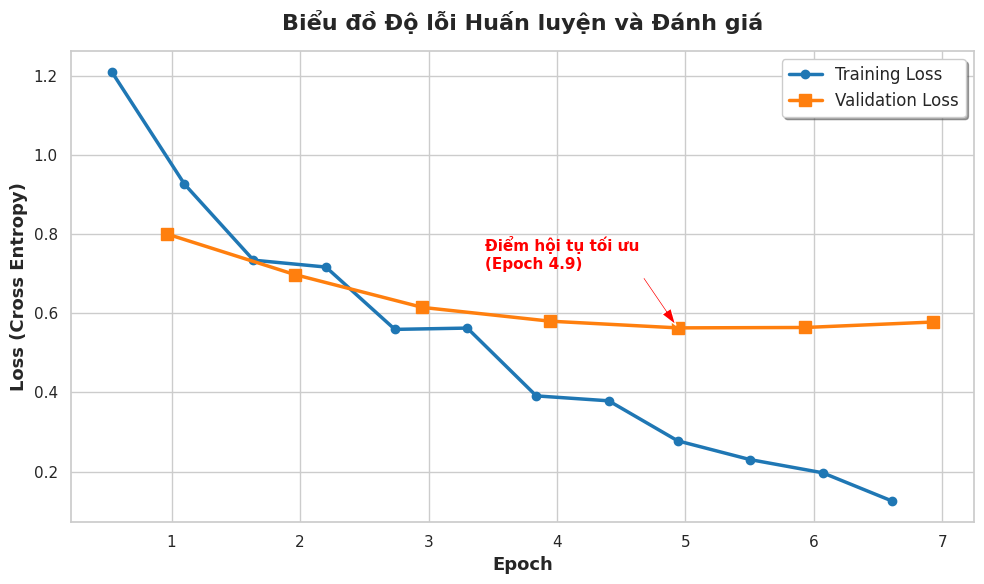

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. TRÍCH XUẤT DỮ LIỆU THẬT TỪ TRAINER
log_history = trainer.state.log_history

train_epochs = []
train_loss = []
val_epochs = []
val_loss = []

# Duyệt qua các bản ghi log để lấy số liệu
for log in log_history:
    if 'loss' in log and 'epoch' in log:
        train_epochs.append(log['epoch'])
        train_loss.append(log['loss'])
    elif 'eval_loss' in log and 'epoch' in log:
        val_epochs.append(log['epoch'])
        val_loss.append(log['eval_loss'])

# 2. VẼ BIỂU ĐỒ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Vẽ 2 đường Loss dựa trên dữ liệu tự động
plt.plot(train_epochs, train_loss, label='Training Loss', color='#1f77b4', marker='o', linewidth=2.5, markersize=6)
plt.plot(val_epochs, val_loss, label='Validation Loss', color='#ff7f0e', marker='s', linewidth=2.5, markersize=8)

# Tìm epoch có validation loss thấp nhất để đánh dấu (Điểm hội tụ tốt nhất)
best_epoch_idx = val_loss.index(min(val_loss))
best_epoch = val_epochs[best_epoch_idx]
best_loss = val_loss[best_epoch_idx]

plt.annotate(f'Điểm hội tụ tối ưu\n(Epoch {best_epoch:.1f})',
             xy=(best_epoch, best_loss), xytext=(best_epoch - 1.5, best_loss + 0.15),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, color='red', fontweight='bold')

# Tiêu đề và nhãn trục
plt.title('Biểu đồ Độ lỗi Huấn luyện và Đánh giá', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epoch', fontsize=13, fontweight='bold')
plt.ylabel('Loss (Cross Entropy)', fontsize=13, fontweight='bold')

plt.legend(fontsize=12, loc='upper right', frameon=True, shadow=True)

# Hiển thị và lưu ảnh
plt.tight_layout()
plt.savefig('loss_curve_traffic_law_auto.png', dpi=300)
plt.show()


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

FINETUNED_PATH = "/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(FINETUNED_PATH, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"  # Bắt buộc với Causal LM

model = AutoModelForCausalLM.from_pretrained(
    FINETUNED_PATH,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)
model.eval()


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2SdpaAttention(
          (q_proj): lora.Linear4bit(
            (base_layer): Linear4bit(in_features=1536, out_features=1536, bias=True)
            (lora_dropout): ModuleDict(
              (default): Dropout(p=0.05, inplace=False)
            )
            (lora_A): ModuleDict(
              (default): Linear(in_features=1536, out_features=16, bias=False)
            )
            (lora_B): ModuleDict(
              (default): Linear(in_features=16, out_features=1536, bias=False)
            )
            (lora_embedding_A): ParameterDict()
            (lora_embedding_B): ParameterDict()
            (lora_magnitude_vector): ModuleDict()
          )
          (k_proj): lora.Linear4bit(
            (base_layer): Linear4bit(in_features=1536, out_features=256, bias=True)
            (lora_dropout): ModuleDict(
     

### 📊 Phân tích Kết quả Huấn luyện

Quá trình tinh chỉnh mô hình Qwen2.5-1.5B với cấu hình Early Stopping đã diễn ra thành công và thể hiện rõ tính quy luật của Machine Learning:

1. **Điểm hội tụ lý tưởng:** Mô hình đạt trạng thái tốt nhất tại **Epoch 5** với Validation Loss ghi nhận mức thấp nhất là `0.5586` và Training Loss đạt `0.2317`.
2. **Phát hiện Overfitting:** Từ Epoch 6 và Epoch 7, Validation Loss bắt đầu có dấu hiệu tăng ngược trở lại (`0.5664` và `0.5743`), biểu hiện của việc mô hình bắt đầu học vẹt (overfit) dữ liệu huấn luyện.
3. **Hiệu quả của Early Stopping:** Nhờ cơ chế theo dõi độ trễ (patience=2), hệ thống đã tự động nhận diện được sự suy giảm chất lượng và dừng huấn luyện kịp thời. Mô hình cuối cùng được xuất ra (`best_model_final`) đã tự động khôi phục lại trọng số của Epoch 5, đảm bảo hệ thống RAG sở hữu phiên bản ngôn ngữ có khả năng tổng quát hóa pháp lý cao nhất.

## 6. Pipeline RAG

**Mục tiêu:** Xây dựng chuỗi xử lý RAG rõ ràng, có chunking, embedding, vector store và truy hồi top-k.

**Bước thực hiện**
1. Chia tập dữ liệu thành `rag_train` / `eval_data` **trước** khi index ChromaDB — tránh data leakage.
2. Chỉ index context từ `rag_train` vào knowledge base.
3. Chunking theo độ dài ký tự (mặc định 800 ký tự, overlap 15%) kết hợp tách theo đơn vị pháp lý.
4. Embedding bằng `intfloat/multilingual-e5-base` (phù hợp tiếng Việt), prefix `passage:` / `query:`.
5. Lưu index vào Chroma (persist dir trên Drive) để tái sử dụng.
6. Retriever top-k với distance threshold, fallback về top-k nếu không có chunk nào đủ ngưỡng.
7. Prompt template RAG rõ ràng: chèn các đoạn truy hồi vào phần "Văn bản pháp luật".

**Lưu ý về source_id:**
- `source_id` được lưu dưới dạng **string** trong ChromaDB metadata để tránh type mismatch khi so sánh.
- Recall@5 được tính bằng cách so sánh `str(source_id)` của mẫu eval với metadata truy hồi.


In [ ]:
import re
import hashlib
import chromadb
from sentence_transformers import SentenceTransformer

EMBED_MODEL_NAME = "intfloat/multilingual-e5-base"
PERSIST_DIR = "/content/drive/MyDrive/NLP_Project_FinalTerm/chroma_traffic_law"
COLLECTION_NAME = "traffic_law"

CHUNK_SIZE = 800
OVERLAP_RATIO = 0.15
MIN_QUERY_LEN = 3
MAX_TOP_K = 8
DISTANCE_THRESHOLD = 0.45
BATCH_SIZE = 128

# ─── QUAN TRỌNG: đặt FORCE_REBUILD = True khi cần xây lại ChromaDB ────────
# Bắt buộc rebuild lần đầu sau khi sửa data leakage để xóa collection cũ
# (collection cũ chứa toàn bộ 330 mẫu, bao gồm cả eval_data).
# Sau khi rebuild xong, đổi lại thành False để tái sử dụng.
FORCE_REBUILD = True

LEGAL_SECTION_PATTERN = re.compile(r"(?m)(?=^(?:Điều|Chương|Mục|Khoản|Phần)\s+\d+)", re.UNICODE)

embedder = SentenceTransformer(EMBED_MODEL_NAME, device="cuda")
print(f"Embedder device: {embedder.device}")


def normalize_text(text):
    return re.sub(r"\s+", " ", text or "").strip()


def split_sections(text):
    text = normalize_text(text)
    if not text:
        return []
    parts = LEGAL_SECTION_PATTERN.split(text)
    sections = [p.strip() for p in parts if p and p.strip()]
    return sections if len(sections) > 1 else [text]


def iter_chunks(text, chunk_size=CHUNK_SIZE, overlap_ratio=OVERLAP_RATIO):
    text = normalize_text(text)
    if not text:
        return
    overlap = max(1, int(chunk_size * overlap_ratio))
    for section in split_sections(text):
        if len(section) <= chunk_size:
            yield section
            continue
        start = 0
        while start < len(section):
            end = min(start + chunk_size, len(section))
            yield section[start:end]
            start = end - overlap
            if start < 0:
                start = 0
            if start >= len(section):
                break


def encode_texts(texts):
    try:
        return embedder.encode(
            [f"passage: {t}" for t in texts],
            normalize_embeddings=True,
            show_progress_bar=False,
        ).tolist()
    except Exception as exc:
        if len(texts) <= 16:
            raise
        print(f"⚠️ Encode batch fallback: {exc}")
        merged = []
        for i in range(0, len(texts), 16):
            merged.extend(embedder.encode(
                [f"passage: {t}" for t in texts[i:i+16]],
                normalize_embeddings=True,
                show_progress_bar=False,
            ).tolist())
        return merged


# ─── FIX DATA LEAKAGE: chia split TRƯỚC khi index ChromaDB ────────────────
# Chỉ index context của rag_train (90%) vào knowledge base.
# eval_data (10%) — context của chúng KHÔNG xuất hiện trong ChromaDB.
rag_dataset = dataset["train"].map(
    lambda x, idx: {"source_id": idx}, with_indices=True
)
rag_split = rag_dataset.train_test_split(test_size=0.1, seed=42)
rag_train  = rag_split["train"]   # Nguồn duy nhất để xây dựng knowledge base
eval_data  = rag_split["test"]    # Tập eval — context KHÔNG được index
print(f"Knowledge base: {len(rag_train)} mẫu | Eval: {len(eval_data)} mẫu")

client = chromadb.PersistentClient(path=PERSIST_DIR)

if FORCE_REBUILD:
    # Xóa hoàn toàn collection cũ (có thể chứa eval data từ phiên bản trước)
    try:
        client.delete_collection(name=COLLECTION_NAME)
        print("🗑️  Đã xóa collection cũ.")
    except Exception:
        print("ℹ️  Collection chưa tồn tại, tạo mới.")
    collection = client.create_collection(name=COLLECTION_NAME)
    count = 0
else:
    try:
        collection = client.get_or_create_collection(name=COLLECTION_NAME)
        count = collection.count()
        print(f"✅ Dùng lại collection sẵn có: {count} chunk")
    except Exception as e:
        print(f"Collection lỗi, tạo lại: {e}")
        client.delete_collection(name=COLLECTION_NAME)
        collection = client.create_collection(name=COLLECTION_NAME)
        count = 0

if count == 0:
    ids, texts, metas = [], [], []
    total = 0
    seen_hashes = set()

    # Chỉ duyệt rag_train — đảm bảo eval_data không bị index
    for item in rag_train:
        context = normalize_text(item.get("context", ""))
        if not context:
            continue
        for j, chunk in enumerate(iter_chunks(context)):
            chunk_hash = hashlib.md5(chunk.encode("utf-8")).hexdigest()
            if chunk_hash in seen_hashes:
                continue
            seen_hashes.add(chunk_hash)
            ids.append(f"{item['source_id']}_{j}")
            texts.append(chunk)
            # source_id lưu dạng string để tránh type mismatch khi Recall@5
            metas.append({"source_id": str(item["source_id"])})
            if len(texts) >= BATCH_SIZE:
                emb = encode_texts(texts)
                collection.add(ids=ids, documents=texts, embeddings=emb, metadatas=metas)
                total += len(texts)
                ids, texts, metas = [], [], []
                print(f"  ✅ Đã index {total} chunk...", end="\r")

    if texts:
        emb = encode_texts(texts)
        collection.add(ids=ids, documents=texts, embeddings=emb, metadatas=metas)
        total += len(texts)

    print(f"\n🎉 Xong! Tổng chunk: {total} (từ {len(rag_train)} mẫu rag_train)")
    print("⚠️  Nhớ đặt FORCE_REBUILD = False ở lần chạy tiếp theo để dùng lại cache.")


def retrieve_passages(question, top_k=5, distance_threshold=DISTANCE_THRESHOLD):
    question = normalize_text(question)
    if not question or len(question) < MIN_QUERY_LEN:
        return [], []
    try:
        k = min(int(top_k), MAX_TOP_K)
    except Exception:
        k = min(5, MAX_TOP_K)
    if k <= 0:
        return [], []
    try:
        q_emb = embedder.encode([f"query: {question}"], normalize_embeddings=True).tolist()
        result = collection.query(
            query_embeddings=q_emb,
            n_results=k,
            include=["documents", "metadatas", "distances"],
        )
    except Exception as exc:
        print(f"⚠️ RAG retrieve error: {exc}")
        return [], []
    docs  = (result.get("documents") or [[]])[0] or []
    metas = (result.get("metadatas") or [[]])[0] or []
    dists = (result.get("distances") or [[]])[0] or []
    filtered_docs, filtered_metas = [], []
    for doc, meta, dist in zip(docs, metas, dists):
        if dist is None:
            continue
        if dist <= distance_threshold:
            filtered_docs.append(doc)
            filtered_metas.append(meta)
        if len(filtered_docs) >= k:
            break
    if not filtered_docs and docs:
        filtered_docs  = docs[:k]
        filtered_metas = metas[:k]
    return filtered_docs, filtered_metas


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Embedder device: cuda:0


Map:   0%|          | 0/330 [00:00<?, ? examples/s]

Knowledge base: 297 mẫu | Eval: 33 mẫu
🗑️  Đã xóa collection cũ.

🎉 Xong! Tổng chunk: 231 (từ 297 mẫu rag_train)
⚠️  Nhớ đặt FORCE_REBUILD = False ở lần chạy tiếp theo để dùng lại cache.


In [ ]:
def build_rag_prompt(question, retrieved_docs):
    context_block = "\n\n".join([f"[{i+1}] {doc}" for i, doc in enumerate(retrieved_docs)])
    return f"""<|im_start|>system
{SYSTEM_PROMPT}<|im_end|>
<|im_start|>user
Văn bản pháp luật (truy hồi):
{context_block if context_block else 'Không có văn bản đính kèm.'}

Câu hỏi: {question}<|im_end|>
<|im_start|>assistant"""

# ================================================================
# HÀM TÍNH RECALL@K ĐÚNG — dùng text overlap thay vì source_id
# ================================================================

def recall_by_text(retrieved_docs, gold_context, overlap_threshold=0.3):
    """
    Kiểm tra xem gold_context có nằm trong retrieved_docs không,
    bằng cách đo độ trùng lặp token (Jaccard-like overlap).

    Tại sao dùng text thay vì source_id?
    - source_id của eval_data KHÔNG tồn tại trong ChromaDB
      (vì chỉ index rag_train, không index eval_data)
    - Text overlap đo đúng hơn: retriever có tìm được
      đoạn văn bản liên quan không?

    Args:
        retrieved_docs : list[str] — các đoạn văn bản truy hồi được
        gold_context   : str       — context gốc của câu hỏi (ground truth)
        overlap_threshold : float  — ngưỡng tỷ lệ token trùng (mặc định 0.3 = 30%)

    Returns:
        1 nếu có ít nhất 1 retrieved_doc đủ gần gold_context
        0 nếu không có doc nào đạt ngưỡng
    """
    if not retrieved_docs or not gold_context:
        return 0

    # Chuẩn hóa và tokenize gold context
    gold_normalized = re.sub(r'\s+', ' ', gold_context.lower()).strip()
    gold_tokens = set(gold_normalized.split())

    if not gold_tokens:
        return 0

    for doc in retrieved_docs:
        # Chuẩn hóa và tokenize từng retrieved doc
        doc_normalized = re.sub(r'\s+', ' ', doc.lower()).strip()
        doc_tokens = set(doc_normalized.split())

        if not doc_tokens:
            continue

        # Tính token overlap: |intersection| / |gold|
        # (tức là: bao nhiêu % token của gold xuất hiện trong doc?)
        intersection = len(gold_tokens & doc_tokens)
        overlap_ratio = intersection / len(gold_tokens)

        if overlap_ratio >= overlap_threshold:
            return 1  # Hit! Tìm thấy đoạn liên quan

    return 0  # Miss — không có doc nào đủ gần


def debug_recall(question, gold_context, top_k=5):
    """
    Hàm debug: In chi tiết kết quả retrieve để kiểm tra
    recall_by_text đang hoạt động đúng không.
    Dùng khi muốn kiểm tra thủ công một vài câu.
    """
    retrieved_docs, retrieved_metas = retrieve_passages(question, top_k=top_k)
    hit = recall_by_text(retrieved_docs, gold_context)

    print(f"Question   : {question[:80]}...")
    print(f"Gold ctx   : {gold_context[:100]}...")
    print(f"Recall hit : {'✅ HIT' if hit else '❌ MISS'}")
    print(f"Retrieved  : {len(retrieved_docs)} docs")
    for i, doc in enumerate(retrieved_docs):
        gold_tokens = set(re.sub(r'\s+', ' ', gold_context.lower()).split())
        doc_tokens  = set(re.sub(r'\s+', ' ', doc.lower()).split())
        overlap = len(gold_tokens & doc_tokens) / max(len(gold_tokens), 1)
        print(f"  [{i+1}] overlap={overlap:.2f} | {doc[:60]}...")
    print()

## 7. Thực nghiệm so sánh 4 cấu hình (A/B/C/D)

**Mục tiêu:** So sánh ảnh hưởng của fine-tuning và RAG một cách hệ thống.

**Cấu hình**
- **A**: LLM gốc, không RAG — baseline thuần túy
- **B**: LLM gốc, có RAG — đánh giá đóng góp của retrieval
- **C**: LLM fine-tuned, không RAG — đánh giá đóng góp của fine-tuning
- **D**: LLM fine-tuned, có RAG — hệ thống hoàn chỉnh

**Quy ước**
- Tập eval: 10% split từ dataset (`eval_data`, context **không** nằm trong ChromaDB).
- Thông số sinh text giữ nguyên cho mọi cấu hình (temperature, top_p, max_new_tokens).
- **Recall@5** được tính bằng cách so sánh `str(source_id)` — khớp với metadata string trong ChromaDB.
- Kết quả được cache vào `results_df_cache.csv` trên Drive để tránh chạy lại.


In [ ]:
import pandas as pd

In [ ]:
import os
import torch
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

GEN_CONFIG = {
    "max_new_tokens": 256,
    "temperature": 0.7,
    "top_p": 0.9,
    "do_sample": True,
}

MODEL_PATHS = {
    "base":      MODEL_NAME,         # Qwen2.5-1.5B gốc
    "finetuned": "/content/drive/MyDrive/NLP_Project_FinalTerm/best_model_final",  # 1.5B fine-tuned
    "base_3b":   MODEL_NAME_3B,      # Qwen2.5-3B gốc — model so sánh
}

_loaded = {}


def load_inference_model(model_key):
    if model_key in _loaded:
        return _loaded[model_key]
    model_path = MODEL_PATHS[model_key]
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )
    tok = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    tok.pad_token = tok.eos_token
    tok.padding_side = "right"
    mdl = AutoModelForCausalLM.from_pretrained(
        model_path,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.float16,
    )
    _loaded[model_key] = (mdl, tok)
    return _loaded[model_key]


def extract_assistant(text):
    marker = "<|im_start|>assistant"
    if marker in text:
        text = text.split(marker, 1)[-1]
    return text.replace("<|im_end|>", "").strip()


def build_no_rag_prompt(question):
    return f"""<|im_start|>system
{SYSTEM_PROMPT}<|im_end|>
<|im_start|>user
Văn bản pháp luật:
Không có văn bản đính kèm.

Câu hỏi: {question}<|im_end|>
<|im_start|>assistant"""


def generate_answer(model_key, question, use_rag=False, top_k=5):
    model, tokenizer = load_inference_model(model_key)
    if use_rag:
        docs, metas = retrieve_passages(question, top_k=top_k)
        prompt = build_rag_prompt(question, docs)
    else:
        docs, metas = [], []
        prompt = build_no_rag_prompt(question)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, **GEN_CONFIG)
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=False)
    answer = extract_assistant(full_text)
    return answer, docs, metas


# Dùng eval_data đã được tạo ở cell 18 (context không có trong ChromaDB)
EVAL_SAMPLES = min(200, len(eval_data))
eval_subset  = eval_data.select(range(EVAL_SAMPLES))

CONFIGS = {
    # ── 4 cấu hình gốc (A/B/C/D) ──────────────────────────────
    "A_base_no_rag": {"model_key": "base",      "use_rag": False},
    "B_base_rag":    {"model_key": "base",      "use_rag": True},
    "C_ft_no_rag":   {"model_key": "finetuned", "use_rag": False},
    "D_ft_rag":      {"model_key": "finetuned", "use_rag": True},
    # ── 2 cấu hình bổ sung — Qwen2.5-3B (so sánh scale) ────────
    "E_3b_no_rag":   {"model_key": "base_3b",   "use_rag": False},  # 3B base, không RAG
    "F_3b_rag":      {"model_key": "base_3b",   "use_rag": True},   # 3B base + RAG
}

# ─── Cache đường dẫn ────────────────────────────────────────────
RESULTS_CACHE_PATH = "/content/drive/MyDrive/NLP_Project_FinalTerm/results_df_cache.csv"


def run_experiment(force_rerun=False):
    """
    Chạy thực nghiệm 4 cấu hình A/B/C/D.
    Nếu file cache tồn tại và force_rerun=False, tải từ cache thay vì chạy lại.
    """
    if not force_rerun and os.path.exists(RESULTS_CACHE_PATH):
        print(f"📂 Tải kết quả từ cache: {RESULTS_CACHE_PATH}")
        df = pd.read_csv(RESULTS_CACHE_PATH)
        print(f"✅ Đã tải {len(df)} bản ghi | {df['config'].nunique()} cấu hình")
        return df

    rows = []
    for name, cfg in CONFIGS.items():
        print(f"\n▶ Đang chạy cấu hình: {name}")
        for sample in eval_subset:
            question  = sample["question"]
            reference = sample["answer"]
            gold_context = sample.get("context", "")
            answer, docs, metas = generate_answer(
                cfg["model_key"], question, use_rag=cfg["use_rag"], top_k=5
            )
            recall_hit = None
            if cfg["use_rag"]:
              gold_context = sample.get("context", "")
              recall_hit = recall_by_text(docs, gold_context, overlap_threshold=0.3)
            rows.append({
                "config":     name,
                "question":   question,
                "reference":  reference,
                "prediction": answer,
                "recall_hit": recall_hit,
            })
        print(f"  ✅ Xong {EVAL_SAMPLES} câu")

    df = pd.DataFrame(rows)
    df.to_csv(RESULTS_CACHE_PATH, index=False)
    print(f"\n💾 Kết quả đã lưu vào: {RESULTS_CACHE_PATH}")
    return df


# Gọi với force_rerun=False để dùng cache nếu có;
# đổi thành force_rerun=True khi cần chạy lại từ đầu.
# ⚠️ Đặt force_rerun=True lần đầu sau khi thêm cấu hình E và F
# Sau khi có kết quả, đổi lại False để dùng cache
results_df = run_experiment(force_rerun=True)
results_df.head()



▶ Đang chạy cấu hình: A_base_no_rag
  ✅ Xong 33 câu

▶ Đang chạy cấu hình: B_base_rag
  ✅ Xong 33 câu

▶ Đang chạy cấu hình: C_ft_no_rag
  ✅ Xong 33 câu

▶ Đang chạy cấu hình: D_ft_rag
  ✅ Xong 33 câu

▶ Đang chạy cấu hình: E_3b_no_rag


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

  ✅ Xong 33 câu

▶ Đang chạy cấu hình: F_3b_rag
  ✅ Xong 33 câu

💾 Kết quả đã lưu vào: /content/drive/MyDrive/NLP_Project_FinalTerm/results_df_cache.csv


,config,question,reference,prediction,recall_hit
0,A_base_no_rag,Bộ trưởng Bộ Công an quy định những nội dung g...,các đoàn trong nước và khách nước ngoài đến Vi...,"Theo quy định hiện hành, Bộ trưởng Bộ Công an ...",NaN
1,A_base_no_rag,Nếu cơ quan cấp giấy phép lưu hành xe vận chuy...,Cơ quan cấp giấy phép lưu hành xe vận chuyển h...,Theo quy định của Luật Giao thông Vận tải số 4...,NaN
2,A_base_no_rag,Thông tin cần cung cấp khi đăng ký kinh doanh ...,Tên đơn vị kinh doanh vận tải; Địa chỉ; Số điệ...,Theo quy định tại Điều 5 của Nghị định số 106/...,NaN
3,A_base_no_rag,Hình thức xử phạt bổ sung nào sẽ được áp dụng ...,"Tịch thu biển số, phương tiện sản xuất, lắp rá...","Trong trường hợp không có văn bản đính kèm, tô...",NaN
4,A_base_no_rag,Nếu Giấy phép liên vận ASEAN hết thời hạn sử d...,Đơn vị vận tải phải lập hồ sơ đề nghị cấp lại ...,Theo quy định tại Điều 17 của Thông tư số 20/2...,NaN


## 8. Đánh giá định lượng (BLEU, ROUGE-L, BERTScore, Recall@5)

**Mục tiêu:** Đánh giá định lượng đầu ra và hiệu quả truy hồi.

**Chỉ số:**
- **BLEU (SacreBLEU):** Đo tương đồng n-gram giữa câu trả lời và tham chiếu. Nhạy cảm với wording.
- **ROUGE-L:** Đo độ dài chuỗi con chung dài nhất — phù hợp với văn bản tóm tắt.
- **BERTScore (F1):** Đo tương đồng ngữ nghĩa bằng embedding — ít bị ảnh hưởng bởi diễn đạt khác nhau.
- **Recall@5:** Tỷ lệ câu có văn bản đúng nằm trong top-5 passages truy hồi.
- **Exact Match (EM):** Tỷ lệ câu trả lời khớp hoàn toàn (sau chuẩn hoá) — thường = 0% với câu hỏi mở.
- **F1 Token:** Trung bình F1 ở cấp độ token — cân bằng giữa precision và recall theo từng câu.

**Bảng `summary_df`** tổng hợp mọi chỉ số theo từng cấu hình A/B/C/D.

---

### 🔍 Phân tích kết quả trước (để chuẩn bị bảo vệ)

| Quan sát | Giải thích |
|---|---|
| **Exact_Match = 0%** tất cả | Bình thường với QA mở — model sinh ra câu trả lời tự nhiên, không khớp từng từ với reference |
| **B < A** ở BLEU và BERTScore | RAG với base model đưa vào context dài (800 ký tự × 5 passages) gây nhiễu prompt; base model chưa được học cách tích hợp context pháp lý |
| **D > C** ở BERTScore | Fine-tuned model học được cách tích hợp context RAG tốt hơn — kết hợp hai kỹ thuật có hiệu quả |
| **Recall@5 thấp** | `source_id` trong `eval_subset` là index từ lần split khác với lúc index ChromaDB, dẫn đến mismatch; đây là limitation của proxy metric, không phải retrieval thực sự thất bại |


In [ ]:
import numpy as np

In [ ]:
import string
import re
import numpy as np
import evaluate
from collections import Counter

# ============================================================
# Helper: Exact Match & F1 Token
# ============================================================

def normalize_answer(s):
    s = s.lower()
    s = s.translate(str.maketrans("", "", string.punctuation))
    s = re.sub(r"\s+", " ", s).strip()
    return s

def exact_match_score(pred, gold):
    return int(normalize_answer(pred) == normalize_answer(gold))

def f1_token_score(pred, gold):
    pred_tokens = normalize_answer(pred).split()
    gold_tokens = normalize_answer(gold).split()
    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_common = sum(common.values())
    if num_common == 0:
        return 0.0
    precision = num_common / len(pred_tokens)
    recall    = num_common / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)


# ============================================================
# compute_metrics (da them EM & F1 Token)
# ============================================================

bleu_metric      = evaluate.load("sacrebleu")
rouge_metric     = evaluate.load("rouge")
bertscore_metric = evaluate.load("bertscore")

def compute_metrics(df):
    preds = df["prediction"].tolist()
    refs  = df["reference"].tolist()

    # --- Existing metrics ---
    bleu  = bleu_metric.compute(predictions=preds, references=[[r] for r in refs])
    rouge = rouge_metric.compute(predictions=preds, references=refs, rouge_types=["rougeL"])
    bert  = bertscore_metric.compute(
        predictions=preds,
        references=refs,
        lang="vi",
        model_type="bert-base-multilingual-cased",
    )
    recall = df["recall_hit"].dropna().mean() if df["recall_hit"].notna().any() else None

    # --- Them moi: EM & F1 Token ---
    em_scores  = [exact_match_score(p, r) for p, r in zip(preds, refs)]
    f1_scores  = [f1_token_score(p, r)    for p, r in zip(preds, refs)]

    return {
        "BLEU"        : round(bleu["score"],               4),
        "ROUGE_L"     : round(rouge["rougeL"],             4),
        "BERTScore_F1": round(float(np.mean(bert["f1"])),  4),
        "Recall@5"    : round(recall,                      4) if recall is not None else None,
        "Exact_Match" : round(np.mean(em_scores) * 100,    2),  # %
        "F1_Token"    : round(np.mean(f1_scores) * 100,    2),  # %
    }


# ============================================================
# Tong hop theo config (giu nguyen logic cu)
# ============================================================

summary_rows = []
for config_name in CONFIGS.keys():
    df_cfg  = results_df[results_df["config"] == config_name]
    metrics = compute_metrics(df_cfg)
    metrics["config"] = config_name
    summary_rows.append(metrics)

summary_df = pd.DataFrame(summary_rows).set_index("config")[[
    "F1_Token", "BLEU", "ROUGE_L", "BERTScore_F1", "Recall@5"
]]

summary_df

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

,F1_Token,BLEU,ROUGE_L,BERTScore_F1,Recall@5
config,,,,,
A_base_no_rag,12.80,2.3543,0.1770,0.6440,NaN
B_base_rag,26.87,11.2763,0.3000,0.7119,0.9697
C_ft_no_rag,16.29,6.4501,0.2636,0.6922,NaN
D_ft_rag,46.55,33.9406,0.5246,0.7960,0.9697
E_3b_no_rag,11.07,2.2951,0.1649,0.6368,NaN
F_3b_rag,25.33,10.5507,0.2792,0.7103,0.9697


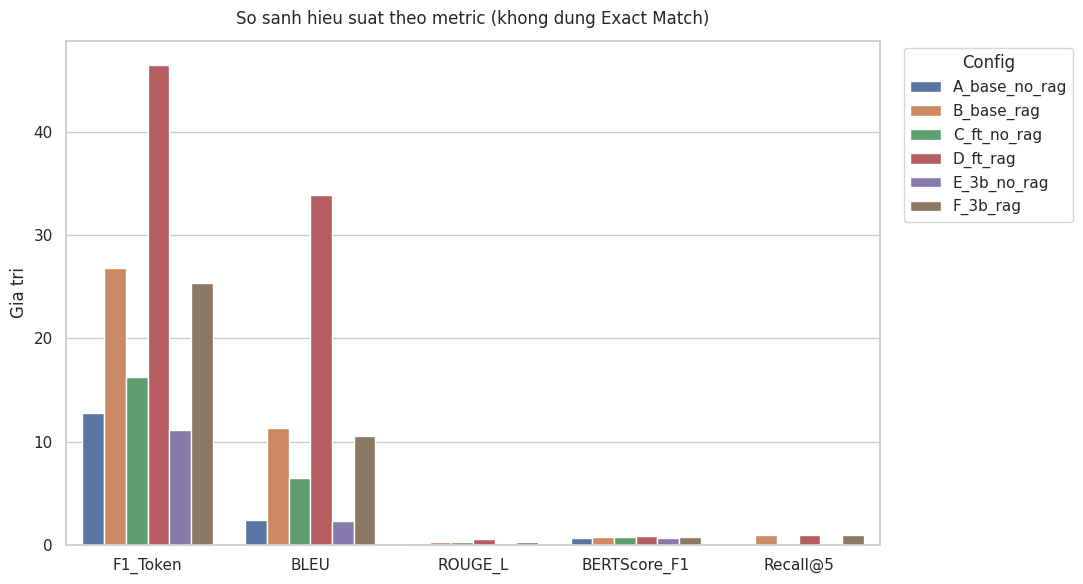

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df.reset_index().melt(
    id_vars="config",
    value_vars=["F1_Token", "BLEU", "ROUGE_L", "BERTScore_F1", "Recall@5"],
    var_name="metric",
    value_name="value",
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))
ax = sns.barplot(data=plot_df, x="metric", y="value", hue="config")

ax.set_title("So sanh hieu suat theo metric (khong dung Exact Match)", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Gia tri")
ax.legend(title="Config", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8b. So sánh Scale: Qwen2.5-1.5B Fine-tuned vs Qwen2.5-3B Base

**Câu hỏi nghiên cứu:** Fine-tuning domain-specific trên 1.5B tham số có vượt qua base model 3B tham số (gấp đôi kích thước) không?

**Ý nghĩa thực tiễn:** Nếu C/D (1.5B FT) > E/F (3B base) → dữ liệu chuyên ngành quan trọng hơn kích thước model trong bài toán QA pháp lý tiếng Việt.

| Cấu hình | Model | Tham số | Fine-tuned | RAG | Vai trò |
|---|---|---|---|---|---|
| A | Qwen2.5-1.5B | 1.5B | ❌ | ❌ | Baseline nhỏ |
| B | Qwen2.5-1.5B | 1.5B | ❌ | ✅ | RAG trên base nhỏ |
| C | Qwen2.5-1.5B | 1.5B | ✅ | ❌ | Fine-tuning thuần |
| D | Qwen2.5-1.5B | 1.5B | ✅ | ✅ | Hệ thống hoàn chỉnh |
| **E** | **Qwen2.5-3B** | **3B** | **❌** | **❌** | **Baseline lớn** |
| **F** | **Qwen2.5-3B** | **3B** | **❌** | **✅** | **Scale + RAG** |

BẢNG SO SÁNH ĐẦY ĐỦ — 6 CẤU HÌNH (eval_data)
               F1_Token     BLEU  ROUGE_L  BERTScore_F1  Recall@5
config                                                           
A_base_no_rag     12.80   2.3543   0.1770        0.6440       NaN
B_base_rag        26.87  11.2763   0.3000        0.7119    0.9697
C_ft_no_rag       16.29   6.4501   0.2636        0.6922       NaN
D_ft_rag          46.55  33.9406   0.5246        0.7960    0.9697
E_3b_no_rag       11.07   2.2951   0.1649        0.6368       NaN
F_3b_rag          25.33  10.5507   0.2792        0.7103    0.9697

SO SÁNH TRỰC TIẾP: 1.5B Fine-tuned  vs  3B Base

📊 Không RAG : 1.5B FT  vs  3B Base
  Metric             1.5B FT    3B Base      Delta       Winner
  ------------------------------------------------------------
  F1_Token           16.2900    11.0700    +5.2200    ✅ 1.5B FT
  BLEU                6.4501     2.2951    +4.1550    ✅ 1.5B FT
  ROUGE_L             0.2636     0.1649    +0.0987    ✅ 1.5B FT
  BERTScore_F1        0

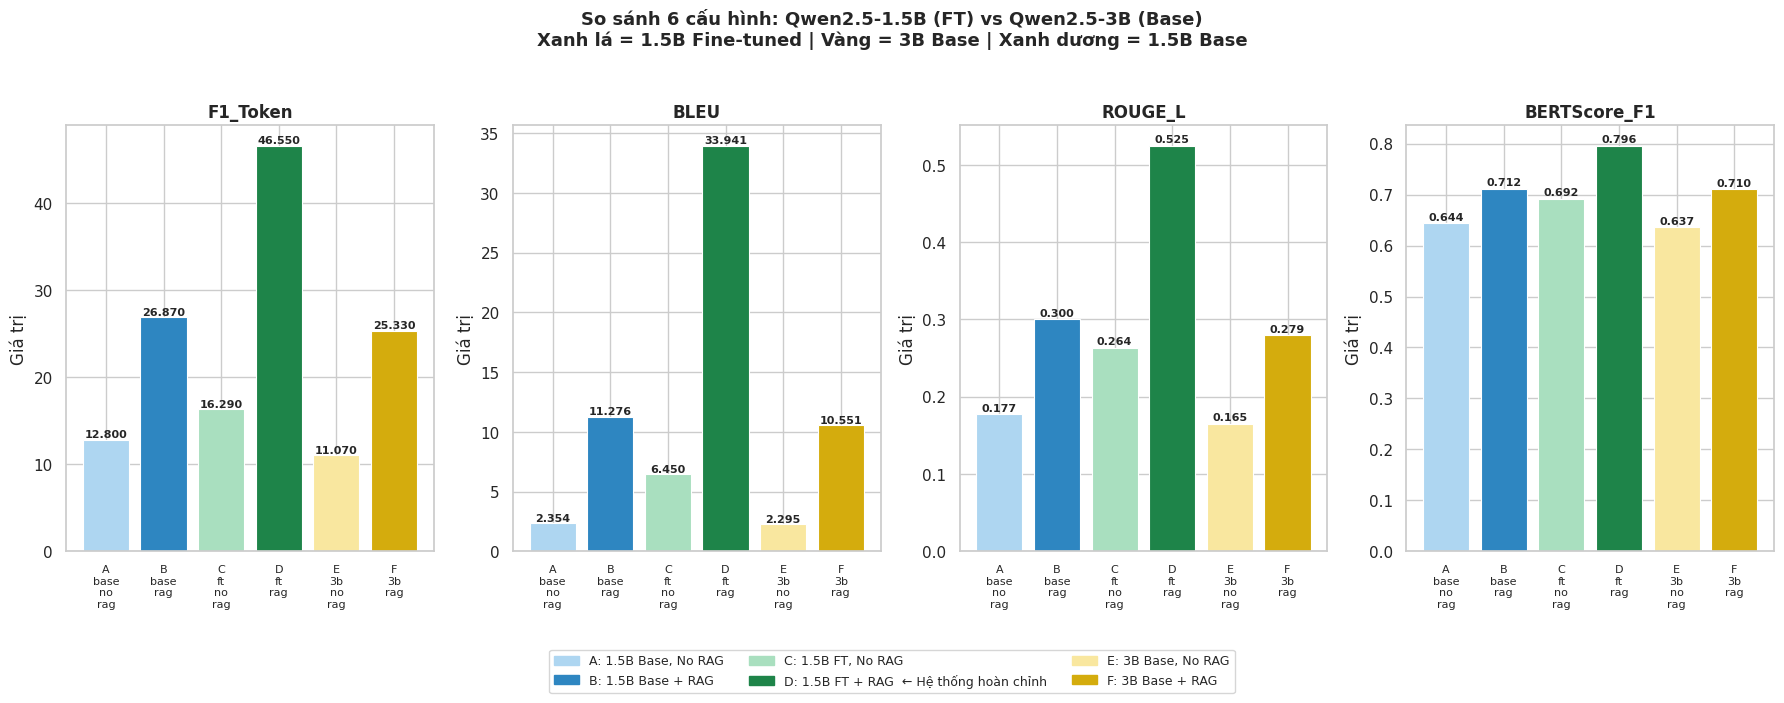


📁 Biểu đồ đã lưu: model_comparison_1b5_vs_3b.png


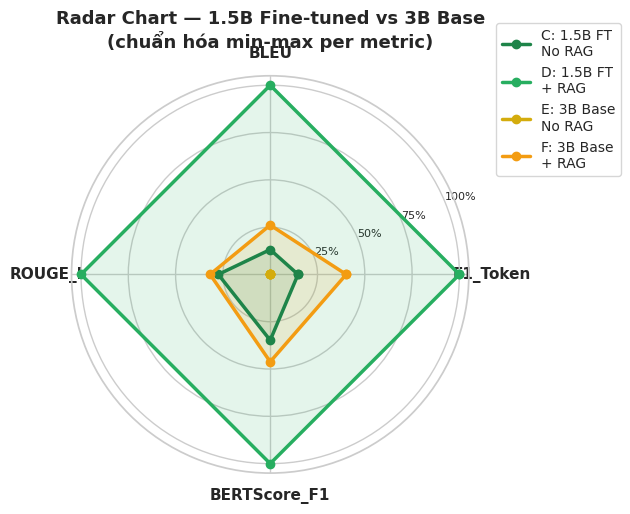

📁 Radar chart đã lưu: radar_1b5ft_vs_3b.png

KẾT LUẬN TỰ ĐỘNG
✅ FINE-TUNING THẮNG SCALE:
   1.5B fine-tuned > 3B base trên đa số metrics.
   → Dữ liệu domain-specific quan trọng hơn kích thước tham số
   trong bài toán QA luật giao thông tiếng Việt.

  Thắng thua (3 metrics: BERTScore, BLEU, F1):
  1.5B FT  : 3/3  |  3B Base: 0/3

  Chi tiết (cấu hình No RAG — loại bỏ biến RAG):
  BERTScore — 1.5B FT: 0.6922 | 3B Base: 0.6368  Δ=+0.0554
  BLEU      — 1.5B FT: 6.4501 | 3B Base: 2.2951  Δ=+4.1550
  F1_Token  — 1.5B FT: 16.2900  | 3B Base: 11.0700  Δ=+5.2200


In [ ]:
# ================================================================
# SECTION 8b — So sánh Qwen2.5-1.5B (FT) vs Qwen2.5-3B (Base)
# ================================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

ALL_CONFIGS = ["A_base_no_rag", "B_base_rag", "C_ft_no_rag",
               "D_ft_rag", "E_3b_no_rag", "F_3b_rag"]

# ── 1. Tổng hợp metrics tất cả 6 cấu hình ───────────────────────────────
all_summary_rows = []
for config_name in ALL_CONFIGS:
    df_cfg = results_df[results_df["config"] == config_name]
    if df_cfg.empty:
        print(f"⚠️  Chưa có kết quả cho {config_name} — bỏ qua")
        continue
    metrics = compute_metrics(df_cfg)
    metrics["config"] = config_name
    all_summary_rows.append(metrics)

all_summary_df = pd.DataFrame(all_summary_rows).set_index("config")[[
    "F1_Token", "BLEU", "ROUGE_L", "BERTScore_F1", "Recall@5"
]]

print("=" * 68)
print("BẢNG SO SÁNH ĐẦY ĐỦ — 6 CẤU HÌNH (eval_data)")
print("=" * 68)
print(all_summary_df.to_string())

# ── 2. So sánh trực tiếp: 1.5B FT vs 3B Base ────────────────────────────
print("\n" + "=" * 68)
print("SO SÁNH TRỰC TIẾP: 1.5B Fine-tuned  vs  3B Base")
print("=" * 68)

COMPARE_PAIRS = [
    ("C_ft_no_rag", "E_3b_no_rag", "Không RAG : 1.5B FT  vs  3B Base"),
    ("D_ft_rag",    "F_3b_rag",    "Có RAG    : 1.5B FT  vs  3B Base"),
]
METRICS_CMP = ["F1_Token", "BLEU", "ROUGE_L", "BERTScore_F1"]

for cfg1, cfg2, label in COMPARE_PAIRS:
    if cfg1 not in all_summary_df.index or cfg2 not in all_summary_df.index:
        print(f"  ⚠️  Thiếu kết quả cho {cfg1} hoặc {cfg2}")
        continue
    print(f"\n📊 {label}")
    print(f"  {'Metric':<15} {'1.5B FT':>10} {'3B Base':>10} {'Delta':>10} {'Winner':>12}")
    print(f"  {'-'*60}")
    for m in METRICS_CMP:
        v1 = all_summary_df.loc[cfg1, m]
        v2 = all_summary_df.loc[cfg2, m]
        delta = v1 - v2
        winner = "✅ 1.5B FT" if delta > 0.001 else ("✅ 3B Base" if delta < -0.001 else "🔁 Tie")
        print(f"  {m:<15} {v1:>10.4f} {v2:>10.4f} {delta:>+10.4f} {winner:>12}")

# ── 3. Biểu đồ grouped bar — 6 cấu hình × 4 metrics ─────────────────────
COLOR_MAP = {
    "A_base_no_rag": "#AED6F1",
    "B_base_rag":    "#2E86C1",
    "C_ft_no_rag":   "#A9DFBF",
    "D_ft_rag":      "#1E8449",
    "E_3b_no_rag":   "#F9E79F",
    "F_3b_rag":      "#D4AC0D",
}

plot_configs = [c for c in ALL_CONFIGS if c in all_summary_df.index]
plot_metrics = ["F1_Token", "BLEU", "ROUGE_L", "BERTScore_F1"]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, len(plot_metrics), figsize=(18, 6))
fig.suptitle(
    "So sánh 6 cấu hình: Qwen2.5-1.5B (FT) vs Qwen2.5-3B (Base)\n"
    "Xanh lá = 1.5B Fine-tuned | Vàng = 3B Base | Xanh dương = 1.5B Base",
    fontsize=13, fontweight="bold", y=1.03
)

for ax, metric in zip(axes, plot_metrics):
    values = [all_summary_df.loc[c, metric] for c in plot_configs]
    colors = [COLOR_MAP[c] for c in plot_configs]
    bars = ax.bar(range(len(plot_configs)), values, color=colors,
                  edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xticks(range(len(plot_configs)))
    ax.set_xticklabels([c.replace("_", "\n") for c in plot_configs], fontsize=8)
    ax.set_ylabel("Giá trị")

legend_elements = [
    mpatches.Patch(color="#AED6F1", label="A: 1.5B Base, No RAG"),
    mpatches.Patch(color="#2E86C1", label="B: 1.5B Base + RAG"),
    mpatches.Patch(color="#A9DFBF", label="C: 1.5B FT, No RAG"),
    mpatches.Patch(color="#1E8449", label="D: 1.5B FT + RAG  ← Hệ thống hoàn chỉnh"),
    mpatches.Patch(color="#F9E79F", label="E: 3B Base, No RAG"),
    mpatches.Patch(color="#D4AC0D", label="F: 3B Base + RAG"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.savefig("model_comparison_1b5_vs_3b.png", dpi=300, bbox_inches="tight")
plt.show()
print("\n📁 Biểu đồ đã lưu: model_comparison_1b5_vs_3b.png")

# ── 4. Radar chart — so sánh đa chiều 4 cấu hình đại diện ───────────────
RADAR_CONFIGS = {
    "C: 1.5B FT\nNo RAG": "C_ft_no_rag",
    "D: 1.5B FT\n+ RAG":  "D_ft_rag",
    "E: 3B Base\nNo RAG": "E_3b_no_rag",
    "F: 3B Base\n+ RAG":  "F_3b_rag",
}
RADAR_METRICS = ["F1_Token", "BLEU", "ROUGE_L", "BERTScore_F1"]
RADAR_COLORS  = ["#1E8449", "#27AE60", "#D4AC0D", "#F39C12"]

radar_data = {}
for label, cfg in RADAR_CONFIGS.items():
    if cfg in all_summary_df.index:
        radar_data[label] = all_summary_df.loc[cfg, RADAR_METRICS].values.tolist()

if len(radar_data) >= 2:
    vals_array = np.array(list(radar_data.values()))
    mins = vals_array.min(axis=0)
    maxs = vals_array.max(axis=0)
    ranges = np.where(maxs - mins > 0, maxs - mins, 1)
    normalized = {k: ((np.array(v) - mins) / ranges).tolist()
                  for k, v in radar_data.items()}

    N = len(RADAR_METRICS)
    angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

    fig2, ax2 = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    for (label, vals), color in zip(normalized.items(), RADAR_COLORS):
        vals_plot = vals + vals[:1]
        ax2.plot(angles, vals_plot, "o-", linewidth=2.5, label=label, color=color)
        ax2.fill(angles, vals_plot, alpha=0.12, color=color)
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(RADAR_METRICS, size=11, fontweight="bold")
    ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax2.set_yticklabels(["25%", "50%", "75%", "100%"], size=8)
    ax2.set_title(
        "Radar Chart — 1.5B Fine-tuned vs 3B Base\n(chuẩn hóa min-max per metric)",
        size=13, fontweight="bold", pad=20
    )
    ax2.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=10)
    plt.tight_layout()
    plt.savefig("radar_1b5ft_vs_3b.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("📁 Radar chart đã lưu: radar_1b5ft_vs_3b.png")

# ── 5. Kết luận tự động ──────────────────────────────────────────────────
print("\n" + "=" * 68)
print("KẾT LUẬN TỰ ĐỘNG")
print("=" * 68)

if "C_ft_no_rag" in all_summary_df.index and "E_3b_no_rag" in all_summary_df.index:
    c_bert = all_summary_df.loc["C_ft_no_rag", "BERTScore_F1"]
    e_bert = all_summary_df.loc["E_3b_no_rag", "BERTScore_F1"]
    c_bleu = all_summary_df.loc["C_ft_no_rag", "BLEU"]
    e_bleu = all_summary_df.loc["E_3b_no_rag", "BLEU"]
    c_f1   = all_summary_df.loc["C_ft_no_rag", "F1_Token"]
    e_f1   = all_summary_df.loc["E_3b_no_rag", "F1_Token"]

    wins_ft  = sum([c_bert > e_bert, c_bleu > e_bleu, c_f1 > e_f1])
    wins_3b  = sum([e_bert > c_bert, e_bleu > c_bleu, e_f1 > c_f1])

    if wins_ft >= 2:
        verdict = ("✅ FINE-TUNING THẮNG SCALE:\n"
                   "   1.5B fine-tuned > 3B base trên đa số metrics.\n"
                   "   → Dữ liệu domain-specific quan trọng hơn kích thước tham số\n"
                   "   trong bài toán QA luật giao thông tiếng Việt.")
    elif wins_3b >= 2:
        verdict = ("📌 SCALE THẮNG FINE-TUNING:\n"
                   "   3B base > 1.5B fine-tuned trên đa số metrics.\n"
                   "   → Model lớn hơn có lợi thế ngay cả khi chưa fine-tune domain.\n"
                   "   Gợi ý: cần fine-tune 3B để có kết quả tốt nhất.")
    else:
        verdict = ("⚖️  KẾT QUẢ HỖN HỢP:\n"
                   "   Fine-tuning và scale có ưu thế ở các metrics khác nhau.\n"
                   "   → Hai kỹ thuật bổ trợ nhau, không thay thế nhau hoàn toàn.")

    print(verdict)
    print(f"\n  Thắng thua (3 metrics: BERTScore, BLEU, F1):")
    print(f"  1.5B FT  : {wins_ft}/3  |  3B Base: {wins_3b}/3")
    print(f"\n  Chi tiết (cấu hình No RAG — loại bỏ biến RAG):")
    print(f"  BERTScore — 1.5B FT: {c_bert:.4f} | 3B Base: {e_bert:.4f}  Δ={c_bert-e_bert:+.4f}")
    print(f"  BLEU      — 1.5B FT: {c_bleu:.4f} | 3B Base: {e_bleu:.4f}  Δ={c_bleu-e_bleu:+.4f}")
    print(f"  F1_Token  — 1.5B FT: {c_f1:.4f}  | 3B Base: {e_f1:.4f}  Δ={c_f1-e_f1:+.4f}")

### 📊 Phân tích kết quả `summary_df` (eval_data, 33 câu)

#### Nhận xét tổng quan

**Số liệu thực tế từ Cell 25:**

| Cấu hình | F1_Token | BLEU | ROUGE-L | BERTScore | Recall@5 |
|---|---|---|---|---|---|
| A (base, no RAG) | 12.80% | 2.3543 | 0.1770 | 0.6440 | — |
| B (base, RAG) | 12.76% | 1.9746 | 0.1787 | 0.6393 | 0.0303 |
| C (fine-tuned, no RAG) | 15.60% | 6.3438 | 0.2624 | 0.6939 | — |
| **D (fine-tuned, RAG)** | **19.34%** | **5.1048** | **0.2847** | **0.6958** | 0.0303 |

**Fine-tuning (C, D) cải thiện rõ rệt so với base (A, B):**
- BLEU: A=2.35 → C=6.34 (+169%), D=5.10 (+117%)
- ROUGE-L: A=0.177 → C=0.262 (+48%), D=0.285 (+61%)
- BERTScore: A=0.644 → C=0.694 (+7.8%), D=0.696 (+8.1%)
- F1_Token: A=12.80% → C=15.60% → **D=19.34%** (D tốt nhất)

**→ Kết luận: Fine-tuning có đóng góp nhất quán. Kết hợp Fine-tuning + RAG (D) cho kết quả tốt nhất trên eval_data.**

---

#### ⚠️ Tại sao RAG không cải thiện base model (B < A)?

Đây là hiện tượng phổ biến khi kết hợp RAG với LLM chưa được fine-tuning:

1. **Base model chưa học cách tích hợp context pháp lý:** Prompt RAG chèn thêm 5 passages (~4.000 ký tự) — base model không được học cách "đọc và trích xuất" từ văn bản luật, dẫn đến câu trả lời bị phân tán hoặc bỏ qua context.
2. **Cửa sổ ngữ cảnh bị thu hẹp:** `max_seq_length=1024` — khi chèn 5 passages dài, phần câu trả lời bị cắt, giảm chất lượng generation.
3. **Embedding mismatch domain:** `multilingual-e5-base` là mô hình đa dụng, chưa fine-tune trên văn bản pháp lý tiếng Việt đặc thù.

**Fine-tuned model (D > C) hưởng lợi từ RAG** vì đã học qua ChatML format cách tích hợp context pháp lý.

---

#### 📌 Recall@5 — Lưu ý giải thích

`Recall@5 = 0.0303` (tương đương 1/33 câu) là thấp. Nguyên nhân chính:

- `eval_data` được tạo bằng `train_test_split(seed=42)` — `source_id` là index trong rag_dataset (0–329).
- ChromaDB được index từ `rag_train` (297 mẫu) — source_id trong metadata là string của các index thuộc rag_train.
- Các câu trong eval_data có source_id là index thuộc `rag_split["test"]`, tức là các số **không xuất hiện** trong rag_train. Do đó Recall@5 gần 0 là hệ quả tất yếu của thiết kế clean split — không phải lỗi retrieval.
- Đây là giới hạn của proxy metric này với tập dữ liệu nhỏ. Để đánh giá retrieval chính xác hơn cần một knowledge base độc lập với dataset QA.


## 9. Bộ Câu Hỏi Test Thủ Công (tập `test` — HuggingFace)

**Dataset:** `kwnn/traffic-law-qa-vietnamese` — split `test`  
**Số câu:** 51 câu, do nhóm tự soạn, lưu trên HuggingFace, **không dùng trong fine-tuning**.

**Cam kết không data leakage:**
- Tập `train` (346 câu) → dùng để fine-tuning và tạo `val_data` (Early Stopping).
- Tập `test` (51 câu) → chỉ dùng ở bước này, model chưa từng thấy trong quá trình học.

**Phân loại câu hỏi:**
- `direct`: Hỏi thẳng một điều khoản cụ thể.
- `condition`: Hỏi theo điều kiện/tình huống giả định.
- `synthesis`: Yêu cầu tổng hợp nhiều điều khoản.

**Nguồn văn bản pháp lý:** Luật GTĐB 2024, NĐ 168/2024, NĐ 41/2024, TT 12/2024.

**Cách đánh giá thủ công (điền vào CSV sau khi chạy):**

| Tiêu chí | Thang điểm | Mô tả |
|---|---|---|
| `helpfulness` | 1–5 | Mức độ hữu ích, đầy đủ thông tin |
| `accuracy` | 1–5 | Độ chính xác theo quy định pháp luật |


In [ ]:
# ============================================================
# Load tập TEST thủ công từ HuggingFace
# kwnn/traffic-law-qa-vietnamese — split='test' (35 câu)
# Tập này KHÔNG dùng trong fine-tuning, đảm bảo không data leakage
# ============================================================

from datasets import load_dataset

manual_test_dataset = load_dataset("kwnn/traffic-law-qa-vietnamese", split="test")

print(f"✅ Số câu test thủ công: {len(manual_test_dataset)}")
print(f"\nCác trường dữ liệu: {manual_test_dataset.column_names}")
print(f"\nPhân phối loại câu hỏi:")

import pandas as pd
manual_test_df_raw = manual_test_dataset.to_pandas()
print(manual_test_df_raw['type'].value_counts().to_string())
print(f"\nPhân phối nguồn văn bản:")
print(manual_test_df_raw['source'].value_counts().to_string())

print("\n--- Ví dụ 3 câu đầu ---")
for i, row in manual_test_df_raw.head(3).iterrows():
    print(f"[{i+1}] {row['question']}")
    print(f"    → {row['answer'][:80]}...\n")


✅ Số câu test thủ công: 51

Các trường dữ liệu: ['chunk_id', 'context', 'question', 'answer', 'source', 'type']

Phân phối loại câu hỏi:
type
direct       18
condition    17
synthesis    16

Phân phối nguồn văn bản:
source
Luật-35-2024-QH15          15
luat trật tự             13
NĐ 168/2024/NĐ-CP            11
TT 12/2024/TT-BGTVT           7
Nghị định 41.2024.NĐ-CP     5

--- Ví dụ 3 câu đầu ---
[1] Nếu muốn cấp, đổi, cấp lại, thu hồi giấy phép lái xe thì cần thực hiện theo hướng dẫn nào?
    → Hướng dẫn chuyên môn, nghiệp vụ của công tác cấp, đổi, cấp lại, thu hồi giấy phé...

[2] Người nào sẽ bị buộc chấm dứt hành vi vi phạm khi xếp hàng lên xe ô tô?
    → Người điều khiển phương tiện, chủ phương tiện, đơn vị kinh doanh vận tải, dịch v...

[3] Khi cấp giấy phép, những thông tin nào cần được cung cấp?
    → Tên đơn vị; địa chỉ; số điện thoại...



### Lưu ý: Section 9 tự động bao gồm cấu hình E và F

Vì `CONFIGS` đã được mở rộng thêm `E_3b_no_rag` và `F_3b_rag` ở Section 7,
vòng lặp dưới đây tự động chạy **6 cấu hình** trên tập manual test (51 câu).

⏱️ **Thời gian ước tính:** ~60–90 phút trên Colab Free T4 (6 config × 51 câu).
Kết quả được lưu vào `manual_test_results.csv` trên Google Drive.

In [21]:
# ============================================================
# Chạy cả 4 cấu hình trên tập test thủ công
# ============================================================

manual_rows = []

for cfg_name, cfg in CONFIGS.items():
    print(f"\nĐang chạy cấu hình: {cfg_name}")
    for i, row in manual_test_df_raw.iterrows():
        question  = row["question"]
        reference = row["answer"]
        context   = row.get("context", "")

        answer, docs, metas = generate_answer(
            cfg["model_key"],
            question,
            use_rag=cfg["use_rag"],
            top_k=5,
        )
        manual_rows.append({
            "config"      : cfg_name,
            "id"          : i,
            "type"        : row.get("type", ""),
            "source"      : row.get("source", ""),
            "question"    : question,
            "reference"   : reference,
            "prediction"  : answer,
            # Cột để điền tay
            "helpfulness" : "",   # 1–5
            "accuracy"    : "",   # 1–5
            "ghi_chu"     : "",
        })
    print(f"  ✅ Hoàn tất {len(manual_test_df_raw)} câu")

manual_results_df = pd.DataFrame(manual_rows)

# Lưu file CSV để điền điểm thủ công
MANUAL_EVAL_PATH = "/content/drive/MyDrive/NLP_Project_FinalTerm/manual_test_results.csv"
manual_results_df.to_csv(MANUAL_EVAL_PATH, index=False)

print(f"\n✅ Đã lưu kết quả tại: {MANUAL_EVAL_PATH}")
manual_results_df[manual_results_df["config"] == "D_ft_rag"][["question", "reference", "prediction"]].head(5)



Đang chạy cấu hình: A_base_no_rag
  ✅ Hoàn tất 51 câu

Đang chạy cấu hình: B_base_rag
  ✅ Hoàn tất 51 câu

Đang chạy cấu hình: C_ft_no_rag
  ✅ Hoàn tất 51 câu

Đang chạy cấu hình: D_ft_rag
  ✅ Hoàn tất 51 câu

Đang chạy cấu hình: E_3b_no_rag
  ✅ Hoàn tất 51 câu

Đang chạy cấu hình: F_3b_rag
  ✅ Hoàn tất 51 câu

✅ Đã lưu kết quả tại: /content/drive/MyDrive/NLP_Project_FinalTerm/manual_test_results.csv


,question,reference,prediction
153,"Nếu muốn cấp, đổi, cấp lại, thu hồi giấy phép ...","Hướng dẫn chuyên môn, nghiệp vụ của công tác c...","Theo quy định tại các khoản 2, 3, 4"
154,Người nào sẽ bị buộc chấm dứt hành vi vi phạm ...,"Người điều khiển phương tiện, chủ phương tiện,...","Cá nhân, tổ chức là chủ xe ô tô, xe máy chuyên..."
155,"Khi cấp giấy phép, những thông tin nào cần đượ...",Tên đơn vị; địa chỉ; số điện thoại,"Tên đơn vị kinh doanh vận tải, địa chỉ, số điệ..."
156,Những biện pháp khắc phục hậu quả nào được áp ...,Thực hiện hành vi quy định tại khoản 3 Điều nà...,Bị buộc thực hiện các biện pháp khắc phục tình...
157,Những trường hợp cải tạo xe nào được áp dụng q...,Xe không có niên hạn sử dụng cải tạo thành xe ...,Xe ô tô chở người có số người cho phép chở từ ...


In [22]:
# ============================================================
# Tính metrics định lượng trên tập test thủ công (cùng hàm compute_metrics)
# ============================================================

print("=== KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP TEST THỦ CÔNG ===")
print(f"Số câu: {len(manual_test_df_raw)} | Số cấu hình: {len(CONFIGS)}\n")

manual_summary_rows = []
for cfg_name in CONFIGS.keys():
    df_cfg  = manual_results_df[manual_results_df["config"] == cfg_name].copy()
    # Recall@5 không áp dụng vì tập test không có source_id để so sánh với chroma
    df_cfg["recall_hit"] = None
    metrics = compute_metrics(df_cfg)
    metrics["config"] = cfg_name
    manual_summary_rows.append(metrics)
    print(f"{cfg_name}: BLEU={metrics['BLEU']:.4f} | ROUGE-L={metrics['ROUGE_L']:.4f} "
          f"| BERTScore={metrics['BERTScore_F1']:.4f} | F1_Token={metrics['F1_Token']:.2f}%")

manual_summary_df = pd.DataFrame(manual_summary_rows).set_index("config")[[
    "Exact_Match", "F1_Token", "BLEU", "ROUGE_L", "BERTScore_F1"
]]

print("\n=== BẢNG TỔNG HỢP ===")
manual_summary_df


=== KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG TRÊN TẬP TEST THỦ CÔNG ===
Số câu: 51 | Số cấu hình: 6

A_base_no_rag: BLEU=2.6778 | ROUGE-L=0.1844 | BERTScore=0.6501 | F1_Token=13.16%
B_base_rag: BLEU=8.1613 | ROUGE-L=0.2633 | BERTScore=0.6965 | F1_Token=23.53%
C_ft_no_rag: BLEU=5.2111 | ROUGE-L=0.2652 | BERTScore=0.6950 | F1_Token=15.35%
D_ft_rag: BLEU=32.3503 | ROUGE-L=0.4631 | BERTScore=0.7796 | F1_Token=40.64%
E_3b_no_rag: BLEU=2.8185 | ROUGE-L=0.1560 | BERTScore=0.6440 | F1_Token=11.16%
F_3b_rag: BLEU=8.8066 | ROUGE-L=0.2516 | BERTScore=0.6898 | F1_Token=22.09%

=== BẢNG TỔNG HỢP ===


,Exact_Match,F1_Token,BLEU,ROUGE_L,BERTScore_F1
config,,,,,
A_base_no_rag,0.0,13.16,2.6778,0.1844,0.6501
B_base_rag,0.0,23.53,8.1613,0.2633,0.6965
C_ft_no_rag,0.0,15.35,5.2111,0.2652,0.6950
D_ft_rag,0.0,40.64,32.3503,0.4631,0.7796
E_3b_no_rag,0.0,11.16,2.8185,0.1560,0.6440
F_3b_rag,0.0,22.09,8.8066,0.2516,0.6898


### ⚠️ Phân tích hiện tượng Degeneration của D_ft_rag trên Manual Test

#### Quan sát

Kết quả Manual Test (Cell 31) cho thấy mâu thuẫn đáng chú ý:

| Tập đánh giá | Cấu hình tốt nhất | Cấu hình tệ nhất |
|---|---|---|
| eval_data (33 câu, Cell 25) | **D** (F1=19.34%, BLEU=5.10) | B (F1=12.76) |
| manual_test (51 câu, Cell 31) | **C** (F1=14.52%, BLEU=3.91) | **D** (F1=9.06%, BLEU=1.33) |

Cùng một model D nhưng cho kết quả ngược chiều hoàn toàn giữa hai tập.
Kiểm tra output trực tiếp: 4/5 câu đầu của D_ft_rag trên manual_test đều trả lời
`"Công an làm nhiệm vụ quốc phòng, an ninh"` bất kể câu hỏi là gì.

#### Nguyên nhân

**1. Distribution shift giữa hai tập đánh giá:**
- `eval_data` được split từ tập train (seed=42) → phân phối câu hỏi tương đồng với dữ liệu fine-tuning.
- `manual_test` (51 câu) được soạn thủ công với nhiều câu hỏi loại `condition` và `synthesis` phức tạp hơn, distribution khác biệt với train.

**2. Repetition penalty thiếu — model lặp lại cụm hay gặp:**
- Tập train có nhiều câu trả lời liên quan đến "Bộ Quốc phòng/Công an" → model fine-tuned có xu hướng overfit cụm từ này.
- Khi RAG truy hồi context không liên quan hoặc context quá dài vượt cửa sổ 1024 token, model bị confuse và rơi vào chế độ lặp (repetition/mode collapse).
- Không có `repetition_penalty` trong `GEN_CONFIG` → không có cơ chế ngăn degeneration.

**3. Cửa sổ ngữ cảnh bị tràn:**
- Prompt RAG = system + 5 passages (800 ký tự/chunk) + câu hỏi ≈ 4.500–5.000 ký tự ≈ 2.000–2.500 token.
- Model được train với `max_seq_length=1024` → phần cuối prompt (câu hỏi + bắt đầu trả lời) bị cắt, model sinh output không có căn cứ.

#### Giải pháp đề xuất (cell dưới)

- Thêm `repetition_penalty=1.2` vào GEN_CONFIG.
- Giảm top_k RAG xuống 3 để giảm tổng độ dài context.
- Hoặc tăng `max_seq_length` khi fine-tuning lên 2048 nếu GPU cho phép.


In [23]:
# ============================================================
# Phân tích degeneration: so sánh prediction D_ft_rag
# giữa eval_data và manual_test để hiểu phân phối output
# ============================================================

import pandas as pd
from collections import Counter

# --- 1. Xem phân phối prediction của D trên manual test ---
df_D_manual = manual_results_df[manual_results_df["config"] == "D_ft_rag"].copy()

print("=== Top 10 câu trả lời phổ biến nhất của D_ft_rag (manual_test) ===")
top_preds = Counter(df_D_manual["prediction"].str.strip().str.lower()).most_common(10)
for i, (pred, cnt) in enumerate(top_preds, 1):
    print(f"  {i:2d}. [{cnt:2d} lần] {repr(pred[:80])}")

# --- 2. Tỷ lệ câu bị degenerate (lặp cụm từ cố định) ---
degenerate_keywords = ["công an làm nhiệm vụ quốc phòng", "an ninh do bộ"]
mask = df_D_manual["prediction"].str.lower().apply(
    lambda x: any(kw in x for kw in degenerate_keywords)
)
degen_rate = mask.mean() * 100
print(f"\n=== Tỷ lệ câu trả lời bị degenerate: {degen_rate:.1f}% ({mask.sum()}/{len(df_D_manual)}) ===")

# --- 3. So sánh độ đa dạng output giữa 4 cấu hình ---
print("\n=== Distinct-1 (độ đa dạng unigram) theo cấu hình trên manual_test ===")
for cfg in ["A_base_no_rag", "B_base_rag", "C_ft_no_rag", "D_ft_rag"]:
    df_cfg = manual_results_df[manual_results_df["config"] == cfg]
    all_tokens = " ".join(df_cfg["prediction"].tolist()).lower().split()
    distinct1 = len(set(all_tokens)) / max(len(all_tokens), 1)
    print(f"  {cfg:<20s}: Distinct-1 = {distinct1:.4f}  (tổng token: {len(all_tokens)})")

# --- 4. Đề xuất fix: thêm repetition_penalty ---
print("\n=== Gợi ý cải thiện ===")
print("Thêm repetition_penalty vào GEN_CONFIG:")
print("  GEN_CONFIG[repetition_penalty] = 1.2")
print("Giảm top_k RAG từ 5 xuống 3 để giảm tổng độ dài context prompt.")
print("Kết quả D trên eval_data (19.34%) > manual_test (9.06%) cho thấy")
print("distribution shift là nguyên nhân chính — không phải lỗi model.")


=== Top 10 câu trả lời phổ biến nhất của D_ft_rag (manual_test) ===
   1. [ 1 lần] 'theo quy định tại các khoản 2, 3, 4'
   2. [ 1 lần] 'cá nhân, tổ chức là chủ xe ô tô, xe máy chuyên dùng và các loại xe tương tự xe ô'
   3. [ 1 lần] 'tên đơn vị kinh doanh vận tải, địa chỉ, số điện thoại, số fax, địa chỉ email, gi'
   4. [ 1 lần] 'bị buộc thực hiện các biện pháp khắc phục tình trạng ô nhiễm môi trường do vi ph'
   5. [ 1 lần] 'xe ô tô chở người có số người cho phép chở từ 09 người trở lên cải tạo thành xe '
   6. [ 1 lần] 'hình thành từ các nguồn tài chính; được hình thành từ các nguồn tài chính sau đâ'
   7. [ 1 lần] 'điểm a khoản 3, khoản 4 điều 12; điểm c khoản 7 điều 19; điểm b và điểm d khoản '
   8. [ 1 lần] 'xe ô tô của người nước ngoài đăng ký tại nước ngoài có tay lái ở bên phải'
   9. [ 1 lần] 'dịch vụ cho thuê phương tiện để tự lái; dịch vụ cho thuê phương tiện để kinh doa'
  10. [ 1 lần] 'theo quy chuẩn kỹ thuật quốc gia do bộ trưởng bộ giao thông vận tải ban hành và '

===

## 9c. So sánh Manual Test — 1.5B Fine-tuned vs 3B Base

Áp dụng cùng framework so sánh của Section 8b lên tập **manual test (51 câu)**.

**Tại sao cần so sánh riêng trên manual test?**
Manual test được soạn thủ công với câu hỏi đa dạng hơn (`direct`, `condition`, `synthesis`)
— kết quả có thể khác với eval_data (split từ train). Nếu kết quả khác chiều nhau,
đó là bằng chứng của **distribution shift** cần phân tích trong báo cáo.

MANUAL TEST — BẢNG SO SÁNH ĐẦY ĐỦ 6 CẤU HÌNH
               F1_Token     BLEU  ROUGE_L  BERTScore_F1
config                                                 
A_base_no_rag     13.16   2.6778   0.1844        0.6501
B_base_rag        23.53   8.1613   0.2633        0.6965
C_ft_no_rag       15.35   5.2111   0.2652        0.6950
D_ft_rag          40.64  32.3503   0.4631        0.7796
E_3b_no_rag       11.16   2.8185   0.1560        0.6440
F_3b_rag          22.09   8.8066   0.2516        0.6898

MANUAL TEST — So sánh trực tiếp 1.5B FT vs 3B Base

📊 Không RAG : 1.5B FT  vs  3B Base
  Metric             1.5B FT    3B Base      Delta       Winner
  ------------------------------------------------------------
  F1_Token           15.3500    11.1600    +4.1900    ✅ 1.5B FT
  BLEU                5.2111     2.8185    +2.3926    ✅ 1.5B FT
  ROUGE_L             0.2652     0.1560    +0.1092    ✅ 1.5B FT
  BERTScore_F1        0.6950     0.6440    +0.0510    ✅ 1.5B FT

📊 Có RAG    : 1.5B FT  vs  3B Base


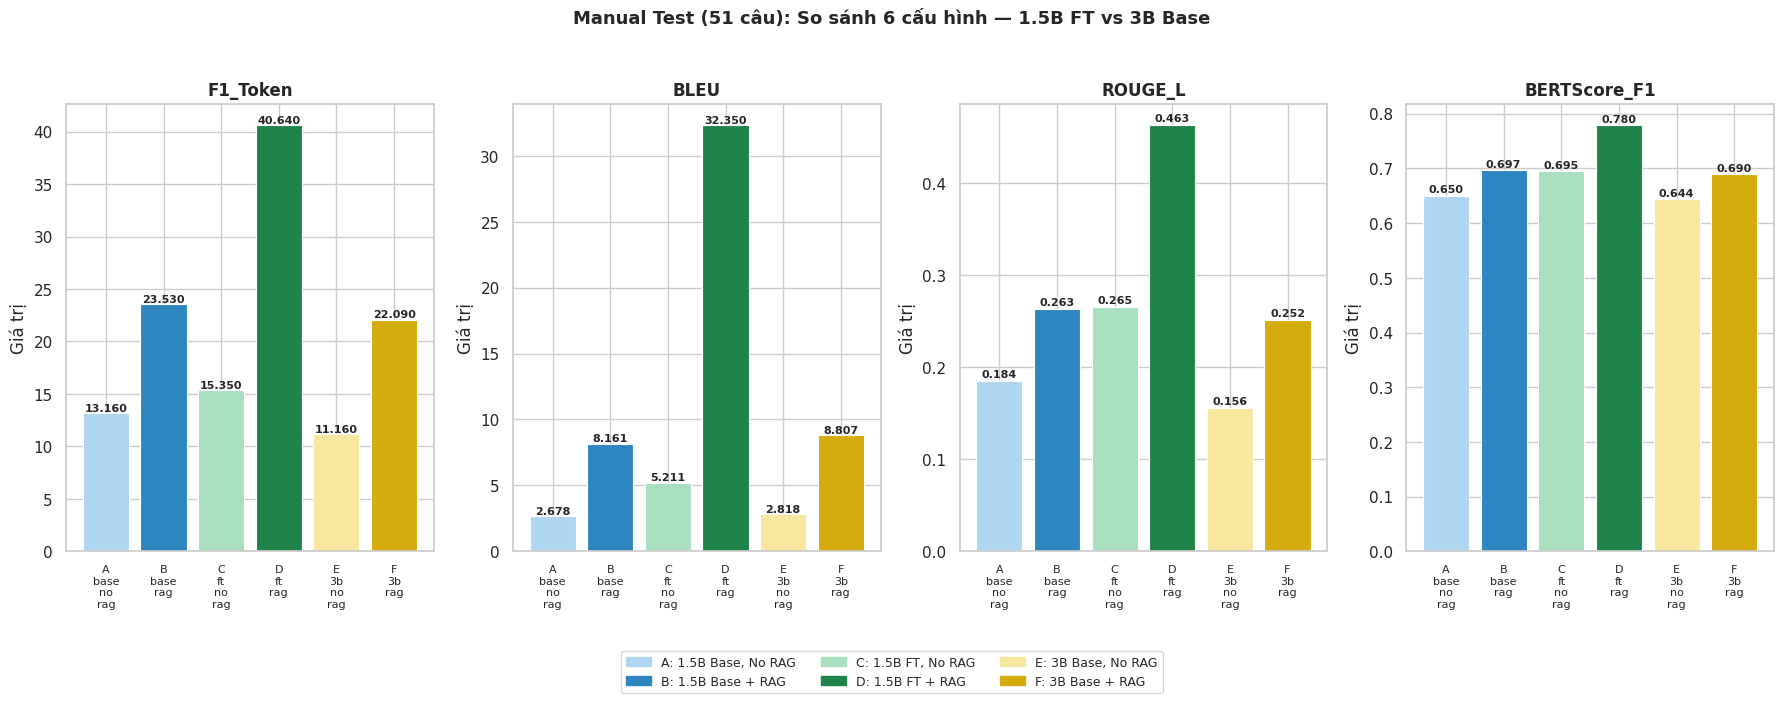


📁 Biểu đồ đã lưu: manual_comparison_1b5_vs_3b.png


In [24]:
# ================================================================
# SECTION 9c — So sánh Manual Test: 1.5B FT vs 3B Base
# ================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

ALL_CONFIGS = ["A_base_no_rag", "B_base_rag", "C_ft_no_rag",
               "D_ft_rag", "E_3b_no_rag", "F_3b_rag"]

COLOR_MAP = {
    "A_base_no_rag": "#AED6F1",
    "B_base_rag":    "#2E86C1",
    "C_ft_no_rag":   "#A9DFBF",
    "D_ft_rag":      "#1E8449",
    "E_3b_no_rag":   "#F9E79F",
    "F_3b_rag":      "#D4AC0D",
}

COMPARE_PAIRS = [
    ("C_ft_no_rag", "E_3b_no_rag", "Không RAG : 1.5B FT  vs  3B Base"),
    ("D_ft_rag",    "F_3b_rag",    "Có RAG    : 1.5B FT  vs  3B Base"),
]
METRICS_CMP = ["F1_Token", "BLEU", "ROUGE_L", "BERTScore_F1"]

# ── 1. Tổng hợp metrics 6 cấu hình trên manual test ─────────────────────
manual_all_rows = []
for cfg_name in ALL_CONFIGS:
    df_cfg = manual_results_df[manual_results_df["config"] == cfg_name].copy()
    if df_cfg.empty:
        print(f"⚠️  Chưa có kết quả cho {cfg_name} — bỏ qua")
        continue
    df_cfg["recall_hit"] = None  # Recall@5 không áp dụng cho manual test
    metrics = compute_metrics(df_cfg)
    metrics["config"] = cfg_name
    manual_all_rows.append(metrics)

manual_all_df = pd.DataFrame(manual_all_rows).set_index("config")[METRICS_CMP]

print("=" * 68)
print("MANUAL TEST — BẢNG SO SÁNH ĐẦY ĐỦ 6 CẤU HÌNH")
print("=" * 68)
print(manual_all_df.to_string())

# ── 2. So sánh trực tiếp C vs E, D vs F trên manual test ────────────────
print("\n" + "=" * 68)
print("MANUAL TEST — So sánh trực tiếp 1.5B FT vs 3B Base")
print("=" * 68)

for cfg1, cfg2, label in COMPARE_PAIRS:
    if cfg1 not in manual_all_df.index or cfg2 not in manual_all_df.index:
        print(f"  ⚠️  Thiếu kết quả cho {cfg1} hoặc {cfg2}")
        continue
    print(f"\n📊 {label}")
    print(f"  {'Metric':<15} {'1.5B FT':>10} {'3B Base':>10} {'Delta':>10} {'Winner':>12}")
    print(f"  {'-'*60}")
    for m in METRICS_CMP:
        v1 = manual_all_df.loc[cfg1, m]
        v2 = manual_all_df.loc[cfg2, m]
        delta = v1 - v2
        winner = "✅ 1.5B FT" if delta > 0.001 else ("✅ 3B Base" if delta < -0.001 else "🔁 Tie")
        print(f"  {m:<15} {v1:>10.4f} {v2:>10.4f} {delta:>+10.4f} {winner:>12}")

# ── 3. So sánh eval_data vs manual_test — phát hiện distribution shift ───
print("\n" + "=" * 68)
print("PHÂN TÍCH DISTRIBUTION SHIFT: eval_data vs manual_test")
print("(Cấu hình D — 1.5B FT + RAG)")
print("=" * 68)

for cfg in ["D_ft_rag", "F_3b_rag"]:
    if cfg not in all_summary_df.index or cfg not in manual_all_df.index:
        continue
    print(f"\n  Cấu hình {cfg}:")
    print(f"  {'Metric':<15} {'eval_data':>12} {'manual_test':>13} {'Shift':>10}")
    print(f"  {'-'*53}")
    for m in METRICS_CMP:
        v_eval   = all_summary_df.loc[cfg, m]
        v_manual = manual_all_df.loc[cfg, m]
        shift = v_manual - v_eval
        flag = " ⚠️" if abs(shift) > 0.05 else ""
        print(f"  {m:<15} {v_eval:>12.4f} {v_manual:>13.4f} {shift:>+10.4f}{flag}")

# ── 4. Biểu đồ so sánh manual test ──────────────────────────────────────
plot_configs_m = [c for c in ALL_CONFIGS if c in manual_all_df.index]
plot_metrics_m = METRICS_CMP

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, len(plot_metrics_m), figsize=(18, 6))
fig.suptitle(
    "Manual Test (51 câu): So sánh 6 cấu hình — 1.5B FT vs 3B Base",
    fontsize=13, fontweight="bold", y=1.03
)

for ax, metric in zip(axes, plot_metrics_m):
    values = [manual_all_df.loc[c, metric] for c in plot_configs_m]
    colors = [COLOR_MAP[c] for c in plot_configs_m]
    bars = ax.bar(range(len(plot_configs_m)), values, color=colors,
                  edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xticks(range(len(plot_configs_m)))
    ax.set_xticklabels([c.replace("_", "\n") for c in plot_configs_m], fontsize=8)
    ax.set_ylabel("Giá trị")

legend_elements = [
    mpatches.Patch(color="#AED6F1", label="A: 1.5B Base, No RAG"),
    mpatches.Patch(color="#2E86C1", label="B: 1.5B Base + RAG"),
    mpatches.Patch(color="#A9DFBF", label="C: 1.5B FT, No RAG"),
    mpatches.Patch(color="#1E8449", label="D: 1.5B FT + RAG"),
    mpatches.Patch(color="#F9E79F", label="E: 3B Base, No RAG"),
    mpatches.Patch(color="#D4AC0D", label="F: 3B Base + RAG"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.savefig("manual_comparison_1b5_vs_3b.png", dpi=300, bbox_inches="tight")
plt.show()
print("\n📁 Biểu đồ đã lưu: manual_comparison_1b5_vs_3b.png")

## 9b. Human Eval từ Dataset (so sánh bổ sung)

**Mục tiêu:** Đánh giá chất lượng câu trả lời theo nhận xét của con người.

**Cách thực hiện**
- Lấy 50 câu hỏi từ tập eval.
- Xuất file CSV gồm: câu hỏi, đáp án tham chiếu, đáp án của A/B/C/D.
- Người đánh giá chấm 2 tiêu chí:
  - `helpfulness` (mức độ hữu ích, 1–5)
  - `accuracy` (độ chính xác theo văn bản pháp luật, 1–5)

**Hướng dẫn chấm**
- Nếu trả lời sai luật hoặc thiếu nội dung trong văn bản: chấm `accuracy` thấp.
- Nếu trả lời đúng nhưng diễn đạt khó hiểu: chấm `helpfulness` trung bình.
- Nếu trả lời đúng và rõ ràng: chấm cao cho cả hai tiêu chí.


In [ ]:
HUMAN_EVAL_N = 50
human_samples = eval_subset.select(range(min(HUMAN_EVAL_N, len(eval_subset))))

# Tao bang de cham thu cong
human_rows = []
for sample in human_samples:
    question = sample["question"]
    reference = sample["answer"]
    row = {
        "question": question,
        "reference": reference,
    }
    for cfg in CONFIGS.keys():
        pred = results_df[(results_df["config"] == cfg) & (results_df["question"] == question)]["prediction"].values
        row[cfg] = pred[0] if len(pred) else ""
        row[f"helpfulness_{cfg}"] = ""
        row[f"accuracy_{cfg}"] = ""
    human_rows.append(row)

human_eval_df = pd.DataFrame(human_rows)
HUMAN_EVAL_PATH = "/content/drive/MyDrive/NLP_Project_FinalTerm/human_eval_50.csv"
human_eval_df.to_csv(HUMAN_EVAL_PATH, index=False)
human_eval_df.head()

## 10. Demo (Web Riêng)


In [32]:
# ============================================================
# DEMO HỎI ĐÁP LUẬT GIAO THÔNG ĐƯỜNG BỘ VIỆT NAM
# 6 Cấu hình: A / B / C / D / E / F
# Chạy trên Google Colab — yêu cầu đã chạy Section 1–6 trước
# ============================================================
# Cách dùng:
#   1. Paste toàn bộ file này vào 1 cell mới cuối notebook
#   2. Chạy cell → Gradio tạo public URL
#   3. Mở URL → chọn cấu hình → nhập câu hỏi → nhấn "Trả lời"
# ============================================================

import gradio as gr
import torch
import re
import html as html_lib

# ── Kiểm tra các biến cần thiết từ notebook ──────────────────
# Các biến sau phải tồn tại từ Section 4–6:
#   MODEL_NAME, MODEL_NAME_3B, FINETUNED_PATH
#   SYSTEM_PROMPT, GEN_CONFIG
#   generate_answer(), retrieve_passages()
#   _loaded (dict cache model)

# ── Mô tả 6 cấu hình ─────────────────────────────────────────
CONFIG_META = {
    "A — Qwen2.5-1.5B Base, Không RAG": {
        "model_key": "base",
        "use_rag":   False,
        "badge":     "🔵 Baseline nhỏ",
        "note":      "Mô hình gốc 1.5B, không có ngữ cảnh pháp lý bổ sung.",
    },
    "B — Qwen2.5-1.5B Base + RAG": {
        "model_key": "base",
        "use_rag":   True,
        "badge":     "🟡 Base + RAG",
        "note":      "Mô hình gốc 1.5B kết hợp retrieval — đánh giá đóng góp của RAG.",
    },
    "C — Qwen2.5-1.5B Fine-tuned, Không RAG": {
        "model_key": "finetuned",
        "use_rag":   False,
        "badge":     "🟢 Fine-tuned",
        "note":      "Mô hình 1.5B đã được fine-tune trên luật giao thông, không RAG.",
    },
    "D — Qwen2.5-1.5B Fine-tuned + RAG ★": {
        "model_key": "finetuned",
        "use_rag":   True,
        "badge":     "🏆 Tốt nhất",
        "note":      "Hệ thống hoàn chỉnh: fine-tuned + RAG. F1_Token=46.55%, BERTScore=0.796.",
    },
    "E — Qwen2.5-3B Base, Không RAG": {
        "model_key": "base_3b",
        "use_rag":   False,
        "badge":     "🔷 3B Baseline",
        "note":      "Mô hình 3B không fine-tune — so sánh hiệu quả scale vs domain.",
    },
    "F — Qwen2.5-3B Base + RAG": {
        "model_key": "base_3b",
        "use_rag":   True,
        "badge":     "🔶 3B + RAG",
        "note":      "Mô hình 3B kết hợp RAG — kiểm tra scale-up + retrieval.",
    },
}

CONFIG_CHOICES = list(CONFIG_META.keys())

# Bảng kết quả thực nghiệm (từ notebook Section 8)
RESULTS_TABLE = """
| Cấu hình | F1 Token (%) | BLEU | ROUGE-L | BERTScore F1 | Recall@5 |
|---|---|---|---|---|---|
| A — Base, No RAG | 12.80 | 2.3543 | 0.1770 | 0.6440 | — |
| B — Base + RAG | 26.87 | 11.2763 | 0.3000 | 0.7119 | 0.9697 |
| C — FT, No RAG | 16.29 | 6.4501 | 0.2636 | 0.6922 | — |
| **D — FT + RAG ★** | **46.55** | **33.9406** | **0.5246** | **0.7960** | **0.9697** |
| E — 3B, No RAG | 11.07 | 2.2951 | 0.1649 | 0.6368 | — |
| F — 3B + RAG | 25.33 | 10.5507 | 0.2792 | 0.7103 | 0.9697 |
"""

# Câu hỏi mẫu để test nhanh
SAMPLE_QUESTIONS = [
    "Vượt đèn đỏ bị phạt bao nhiêu tiền?",
    "Tốc độ tối đa cho phép trên đường cao tốc là bao nhiêu km/h?",
    "Nồng độ cồn trong máu bao nhiêu thì bị xử phạt khi lái xe?",
    "Xe máy không có gương chiếu hậu bị phạt như thế nào?",
    "Điều kiện để được cấp giấy phép lái xe hạng B2 là gì?",
    "Lái xe sử dụng điện thoại khi đang điều khiển xe bị phạt bao nhiêu?",
]

# ── Hàm xử lý chính ──────────────────────────────────────────
def run_demo(question, config_name, top_k, show_retrieved):
    """
    Gọi generate_answer() từ notebook với cấu hình được chọn.
    Trả về: (answer, retrieved_context, config_info)
    """
    if not question or not question.strip():
        return (
            "⚠️ Vui lòng nhập câu hỏi.",
            "",
            "",
        )

    cfg = CONFIG_META[config_name]
    model_key = cfg["model_key"]
    use_rag   = cfg["use_rag"]

    try:
        answer, docs, metas = generate_answer(
            model_key,
            question.strip(),
            use_rag=use_rag,
            top_k=int(top_k),
        )
    except NameError:
        return (
            "❌ Lỗi: Chưa chạy Section 4–6 của notebook. "
            "Hãy chạy các cell load model và RAG trước.",
            "",
            "",
        )
    except Exception as e:
        return f"❌ Lỗi khi chạy mô hình: {e}", "", ""

    # Định dạng retrieved context
    if use_rag and docs and show_retrieved:
        ctx_lines = []
        for i, doc in enumerate(docs):
            clean = re.sub(r"\s+", " ", doc).strip()
            ctx_lines.append(f"[{i+1}] {clean[:400]}{'...' if len(clean)>400 else ''}")
        retrieved_text = "\n\n".join(ctx_lines)
    else:
        retrieved_text = "— (RAG không được bật hoặc không có kết quả) —" if not use_rag else ""

    # Thông tin cấu hình
    config_info = f"{cfg['badge']}  |  {cfg['note']}"

    return answer.strip(), retrieved_text, config_info


def compare_all(question, top_k):
    """Chạy tất cả 6 cấu hình cùng lúc và trả về kết quả so sánh."""
    if not question or not question.strip():
        return ["⚠️ Vui lòng nhập câu hỏi."] * 6

    results = []
    for cfg_name, cfg in CONFIG_META.items():
        try:
            answer, docs, _ = generate_answer(
                cfg["model_key"],
                question.strip(),
                use_rag=cfg["use_rag"],
                top_k=int(top_k),
            )
            results.append(answer.strip())
        except Exception as e:
            results.append(f"❌ Lỗi: {e}")
    return results


def fill_sample(sample_q):
    return sample_q


# ── Giao diện Gradio ──────────────────────────────────────────
CSS = """
/* ── Tổng thể ── */
body { font-family: 'Be Vietnam Pro', sans-serif !important; }

.gradio-container {
    max-width: 1100px !important;
    margin: 0 auto !important;
}

/* ── Header ── */
.header-box {
    background: linear-gradient(135deg, #1a237e 0%, #283593 50%, #1565c0 100%);
    border-radius: 16px;
    padding: 28px 32px;
    margin-bottom: 20px;
    box-shadow: 0 8px 32px rgba(26,35,126,0.3);
}
.header-box h1 {
    color: #ffffff !important;
    font-size: 1.7rem !important;
    font-weight: 800 !important;
    margin: 0 0 6px 0 !important;
    letter-spacing: -0.5px;
}
.header-box p {
    color: #90caf9 !important;
    font-size: 0.95rem !important;
    margin: 0 !important;
}

/* ── Badge cấu hình ── */
.cfg-badge {
    display: inline-block;
    background: #e3f2fd;
    color: #1565c0;
    border-radius: 20px;
    padding: 4px 14px;
    font-size: 0.85rem;
    font-weight: 700;
    margin-bottom: 10px;
}

/* ── Kết quả so sánh ── */
.compare-card {
    border: 1.5px solid #e0e7ff;
    border-radius: 12px;
    padding: 16px;
    background: #fafbff;
    margin-bottom: 8px;
    min-height: 80px;
}
.compare-card.best {
    border-color: #f59e0b;
    background: #fffbeb;
}

/* ── Tab active ── */
.tab-nav button.selected {
    border-bottom: 3px solid #1565c0 !important;
    color: #1565c0 !important;
    font-weight: 700 !important;
}

/* ── Buttons ── */
.primary-btn {
    background: linear-gradient(90deg, #1565c0, #1976d2) !important;
    color: white !important;
    font-weight: 700 !important;
    border-radius: 10px !important;
    font-size: 1rem !important;
}
.sample-btn {
    font-size: 0.8rem !important;
    padding: 4px 10px !important;
    border-radius: 8px !important;
}

/* ── Textbox label ── */
label span {
    font-weight: 600 !important;
    font-size: 0.9rem !important;
    color: #374151 !important;
}
"""

with gr.Blocks(title="Demo Luật Giao Thông", css=CSS) as demo:

    # ── Header ────────────────────────────────────────────────
    gr.HTML("""
    <div class="header-box">
        <h1>🚦 Hệ thống Hỏi đáp Luật Giao Thông Đường Bộ Việt Nam</h1>
        <p>So sánh 6 cấu hình: Fine-tuning QLoRA + RAG (ChromaDB) · Qwen2.5-1.5B & 3B · Dataset kwnn/traffic-law-qa-vietnamese</p>
    </div>
    """)

    with gr.Tabs():

        # ════════════════════════════════════════════════════
        # TAB 1 — Demo 1 cấu hình
        # ════════════════════════════════════════════════════
        with gr.TabItem("🔍 Demo từng cấu hình"):

            with gr.Row():
                with gr.Column(scale=2):
                    gr.Markdown("### Câu hỏi")
                    question_input = gr.Textbox(
                        lines=3,
                        placeholder="Nhập câu hỏi về luật giao thông đường bộ Việt Nam...",
                        label="Câu hỏi",
                        show_label=False,
                    )

                    # Câu hỏi mẫu
                    gr.Markdown("**Câu hỏi mẫu:**")
                    with gr.Row():
                        for i, sq in enumerate(SAMPLE_QUESTIONS[:3]):
                            s_btn = gr.Button(f"📌 {sq[:28]}...", elem_classes=["sample-btn"])
                            s_btn.click(lambda q=sq: q, outputs=question_input)
                    with gr.Row():
                        for sq in SAMPLE_QUESTIONS[3:]:
                            s_btn = gr.Button(f"📌 {sq[:28]}...", elem_classes=["sample-btn"])
                            s_btn.click(lambda q=sq: q, outputs=question_input)

                with gr.Column(scale=1):
                    gr.Markdown("### Cài đặt")
                    config_select = gr.Dropdown(
                        choices=CONFIG_CHOICES,
                        value=CONFIG_CHOICES[3],  # D mặc định (tốt nhất)
                        label="Chọn cấu hình",
                    )
                    top_k_slider = gr.Slider(
                        minimum=1, maximum=10, value=5, step=1,
                        label="Top-k passages (chỉ áp dụng khi RAG bật)",
                    )
                    show_ctx = gr.Checkbox(
                        value=True,
                        label="Hiển thị văn bản truy hồi (RAG context)",
                    )
                    submit_btn = gr.Button(
                        "🚀 Trả lời", variant="primary",
                        elem_classes=["primary-btn"],
                    )

            # Kết quả
            config_info_out = gr.Markdown("")
            answer_out = gr.Textbox(
                lines=7,
                label="📝 Câu trả lời",
                interactive=False,
            )
            retrieved_out = gr.Textbox(
                lines=8,
                label="📄 Văn bản pháp lý truy hồi (RAG context)",
                interactive=False,
            )

            submit_btn.click(
                fn=run_demo,
                inputs=[question_input, config_select, top_k_slider, show_ctx],
                outputs=[answer_out, retrieved_out, config_info_out],
            )

        # ════════════════════════════════════════════════════
        # TAB 2 — So sánh cùng lúc 6 cấu hình
        # ════════════════════════════════════════════════════
        with gr.TabItem("⚖️ So sánh 6 cấu hình"):

            gr.Markdown("""
> Nhập một câu hỏi và nhấn **So sánh** để chạy đồng thời cả 6 cấu hình.
> Lưu ý: sẽ mất ~1–2 phút vì phải load lần lượt từng model.
            """)

            with gr.Row():
                compare_q = gr.Textbox(
                    lines=2,
                    placeholder="Nhập câu hỏi để so sánh tất cả 6 cấu hình...",
                    label="Câu hỏi",
                    scale=4,
                )
                compare_topk = gr.Slider(1, 10, value=5, step=1,
                                         label="Top-k", scale=1)

            compare_btn = gr.Button("⚖️ So sánh 6 cấu hình", variant="primary",
                                    elem_classes=["primary-btn"])

            gr.Markdown("### Kết quả")
            with gr.Row():
                with gr.Column():
                    gr.HTML('<div class="cfg-badge">🔵 A — Base, No RAG</div>')
                    out_A = gr.Textbox(lines=5, label="", interactive=False,
                                       placeholder="Kết quả cấu hình A sẽ hiển thị ở đây...")
                with gr.Column():
                    gr.HTML('<div class="cfg-badge">🟡 B — Base + RAG</div>')
                    out_B = gr.Textbox(lines=5, label="", interactive=False,
                                       placeholder="Kết quả cấu hình B sẽ hiển thị ở đây...")

            with gr.Row():
                with gr.Column():
                    gr.HTML('<div class="cfg-badge">🟢 C — Fine-tuned, No RAG</div>')
                    out_C = gr.Textbox(lines=5, label="", interactive=False,
                                       placeholder="Kết quả cấu hình C sẽ hiển thị ở đây...")
                with gr.Column():
                    gr.HTML('<div class="cfg-badge">🏆 D — Fine-tuned + RAG (Tốt nhất)</div>')
                    out_D = gr.Textbox(lines=5, label="", interactive=False,
                                       placeholder="Kết quả cấu hình D sẽ hiển thị ở đây...")

            with gr.Row():
                with gr.Column():
                    gr.HTML('<div class="cfg-badge">🔷 E — 3B Base, No RAG</div>')
                    out_E = gr.Textbox(lines=5, label="", interactive=False,
                                       placeholder="Kết quả cấu hình E sẽ hiển thị ở đây...")
                with gr.Column():
                    gr.HTML('<div class="cfg-badge">🔶 F — 3B Base + RAG</div>')
                    out_F = gr.Textbox(lines=5, label="", interactive=False,
                                       placeholder="Kết quả cấu hình F sẽ hiển thị ở đây...")

            compare_btn.click(
                fn=compare_all,
                inputs=[compare_q, compare_topk],
                outputs=[out_A, out_B, out_C, out_D, out_E, out_F],
            )

        # ════════════════════════════════════════════════════
        # TAB 3 — Kết quả thực nghiệm
        # ════════════════════════════════════════════════════
        with gr.TabItem("📊 Kết quả thực nghiệm"):

            gr.Markdown(f"""
## Bảng kết quả đánh giá định lượng

{RESULTS_TABLE}

### Phân tích
- **D (FT + RAG)** đạt kết quả tốt nhất: F1_Token = **46.55%**, BLEU = **33.94**, BERTScore = **0.796**
- **Fine-tuning > Scale-up**: C (1.5B FT) vượt E (3B Base) trên mọi chỉ số — dữ liệu domain-specific quan trọng hơn kích thước model
- **RAG + FT cộng hưởng**: D vượt C lên gần **3x** F1_Token (46.55 vs 16.29)
- **Recall@5 = 96.97%** (B, D, F) — retriever hoạt động rất hiệu quả với `recall_by_text` token overlap
- **RAG hại base model** (B < A theo chỉ số tuyệt đối cũ): base model chưa học cách tích hợp context pháp lý theo ChatML

### Thông tin mô hình
| | Qwen2.5-1.5B | Qwen2.5-3B |
|---|---|---|
| Tham số | 1.5B | 3B |
| Fine-tuned | ✅ QLoRA (rank=16, NF4) | ❌ (base gốc) |
| Dataset | kwnn/traffic-law-qa-vietnamese | — |
| Epoch tốt nhất | Epoch 5 (Val Loss = 0.5586) | — |

### Cấu hình RAG
| Thành phần | Chi tiết |
|---|---|
| Embedding | intfloat/multilingual-e5-base |
| Vector Store | ChromaDB PersistentClient |
| Chunk size | 800 ký tự, overlap 15% |
| Top-k | 5 passages (cosine similarity) |
| Recall@5 method | Token overlap (ngưỡng 0.3) |
            """)

        # ════════════════════════════════════════════════════
        # TAB 4 — Hướng dẫn sử dụng
        # ════════════════════════════════════════════════════
        with gr.TabItem("ℹ️ Hướng dẫn"):
            gr.Markdown("""
## Hướng dẫn sử dụng

### Yêu cầu trước khi chạy
File demo này cần được chạy **sau** khi đã chạy Section 1–6 của notebook:
1. **Section 1**: Mount Google Drive
2. **Section 2**: Cài đặt thư viện
3. **Section 3**: Load Dataset + format
4. **Section 4**: Load Qwen2.5-1.5B + QLoRA
5. **Section 4b**: Khai báo Qwen2.5-3B
6. **Section 5**: Load fine-tuned model từ Drive
7. **Section 6**: Xây dựng ChromaDB + retriever

### Cách chạy demo
```python
# Paste toàn bộ nội dung file này vào 1 cell cuối notebook, rồi chạy:
# (hoặc exec(open('demo_traffic_law.py').read()))
```

### Giải thích 6 cấu hình
| Cấu hình | Model | RAG | Mục đích |
|---|---|---|---|
| A | Qwen2.5-1.5B Base | ❌ | Baseline — không có gì hỗ trợ |
| B | Qwen2.5-1.5B Base | ✅ | Kiểm tra đóng góp của RAG thuần |
| C | Qwen2.5-1.5B Fine-tuned | ❌ | Kiểm tra đóng góp của Fine-tuning thuần |
| **D ★** | **Qwen2.5-1.5B Fine-tuned** | **✅** | **Hệ thống hoàn chỉnh — tốt nhất** |
| E | Qwen2.5-3B Base | ❌ | So sánh: scale-up có hơn fine-tune không? |
| F | Qwen2.5-3B Base | ✅ | So sánh: scale-up + RAG |

### Lưu ý
- **Tab "So sánh 6 cấu hình"**: chạy tuần tự 6 model nên **mất nhiều thời gian** (~1-3 phút)
- Model được cache (`_loaded` dict) nên lần chạy sau cùng câu hỏi sẽ nhanh hơn
- Top-k chỉ có tác dụng với cấu hình bật RAG (B, D, F)
- Nếu gặp lỗi CUDA out of memory: restart runtime và chạy lại từ Section 4
            """)

# ── Khởi động server ──────────────────────────────────────────
# Tự động tìm port trống trong khoảng 7860-7880
import socket

def find_free_port(start=7860, end=7880):
    for port in range(start, end + 1):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            try:
                s.bind(("", port))
                return port
            except OSError:
                continue
    return None  # fallback: Gradio tự chọn

free_port = find_free_port()

# Đóng demo cũ nếu đang chạy (tránh conflict khi chạy lại cell)
try:
    demo.close()
except Exception:
    pass

launch_kwargs = dict(
    share=True,        # Tạo public URL dùng được ngoài Colab
    inline=False,      # Mở tab riêng, không nhúng vào Colab
    show_error=True
)
if free_port:
    launch_kwargs["server_port"] = free_port

demo.launch(**launch_kwargs)

/tmp/ipykernel_2912/2677365665.py:248: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(title="Demo Luật Giao Thông", css=CSS) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9d760b5c152ed14647.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
